In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path
import numpy as np
import pyarrow.parquet as pq
import re
from collections import Counter
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Clone AI Text Detection dataset from Hugging Face
!git clone https://huggingface.co/datasets/artem9k/ai-text-detection-pile

Cloning into 'ai-text-detection-pile'...
remote: Enumerating objects: 37, done.
remote: Total 37 (delta 0), reused 0 (delta 0), pack-reused 37 (from 1)
Receiving objects: 100% (37/37), 5.48 KiB | 2.74 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Filtering content: 100% (7/7), 1.83 GiB | 27.09 MiB/s, done.


In [ ]:
# Load a single parquet file into a DataFrame
df = pd.read_parquet("/content/ai-text-detection-pile/data/train-00000-of-00007-bc5952582e004d67.parquet")

print(df.head())

  source  id                                               text
0  human   0  12 Years a Slave: An Analysis of the Film Essa...
1  human   1  20+ Social Media Post Ideas to Radically Simpl...
2  human   2  2022 Russian Invasion of Ukraine in Global Med...
3  human   3  533 U.S. 27 (2001) Kyllo v. United States: The...
4  human   4  A Charles Schwab Corporation Case Essay\n\nCha...


In [ ]:
# Scan all parquet files to expose class imbalance between human and AI texts
results = []
parquet_files = sorted(glob.glob('/content/ai-text-detection-pile/data/*.parquet'))

for file in parquet_files:
    print(f"Processing file: {file}")

    table = pq.read_table(file, columns=['source', 'text'])
    df = table.to_pandas()

    human_count = (df['source'] == 'human').sum()
    ai_count = (df['source'] == 'ai').sum()

    results.append({
        'filename': Path(file).name,
        'human_count': human_count,
        'ai_count': ai_count,
        'human_texts': df[df['source'] == 'human']['text'].notna().sum(),
        'ai_texts': df[df['source'] == 'ai']['text'].notna().sum(),
        'total_rows': len(df)
    })

    del df, table

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))
summary_df.to_csv('parquet_summary.csv', index=False)

Processing file: /content/ai-text-detection-pile/data/train-00000-of-00007-bc5952582e004d67.parquet
Processing file: /content/ai-text-detection-pile/data/train-00001-of-00007-71c80017bc45f30d.parquet
Processing file: /content/ai-text-detection-pile/data/train-00002-of-00007-ee2d43f396e78fbc.parquet
Processing file: /content/ai-text-detection-pile/data/train-00003-of-00007-529931154b42b51d.parquet
Processing file: /content/ai-text-detection-pile/data/train-00004-of-00007-b269dc49374a2c0b.parquet
Processing file: /content/ai-text-detection-pile/data/train-00005-of-00007-3dce5e05ddbad789.parquet
Processing file: /content/ai-text-detection-pile/data/train-00006-of-00007-3d8a471ba0cf1c8d.parquet
                                     filename  human_count  ai_count  human_texts  ai_texts  total_rows
train-00000-of-00007-bc5952582e004d67.parquet       198932         0       198932         0      198932
train-00001-of-00007-71c80017bc45f30d.parquet       198932         0       198932         0 

In [ ]:
# Balance the dataset by proportionally sampling equal human and AI texts across all parquet files

# First pass: count human and AI rows in each file
file_stats = []
for file in parquet_files:
    table = pq.read_table(file, columns=['source'])
    df = table.to_pandas()

    file_stats.append({
        'file': file,
        'human_count': (df['source'] == 'human').sum(),
        'ai_count': (df['source'] == 'ai').sum()
    })
    del df, table

total_human = sum(s['human_count'] for s in file_stats)
total_ai = sum(s['ai_count'] for s in file_stats)
min_count = min(total_human, total_ai)

print(f"Total human: {total_human}")
print(f"Total AI: {total_ai}")
print(f"Sampling {min_count} from each")

# Second pass: reads only source + text columns and frees memory after each file
import gc
all_human_samples = []
all_ai_samples = []

for stats in file_stats:
    table = pq.read_table(stats['file'], columns=['source', 'text'])
    df = table.to_pandas()
    del table
    gc.collect()

    human_sample_size = int((stats['human_count'] / total_human) * min_count)
    ai_sample_size = int((stats['ai_count'] / total_ai) * min_count)

    human_df = df[df['source'] == 'human']
    ai_df = df[df['source'] == 'ai']

    if len(human_df) > 0 and human_sample_size > 0:
        all_human_samples.append(human_df.sample(n=min(human_sample_size, len(human_df)), random_state=42))

    if len(ai_df) > 0 and ai_sample_size > 0:
        all_ai_samples.append(ai_df.sample(n=min(ai_sample_size, len(ai_df)), random_state=42))

    del df, human_df, ai_df
    gc.collect()

# Combine and enforce exact equal counts
combined_human = pd.concat(all_human_samples, ignore_index=True)
del all_human_samples
gc.collect()
combined_ai = pd.concat(all_ai_samples, ignore_index=True)
del all_ai_samples
gc.collect()

final_count = min(len(combined_human), len(combined_ai))
balanced_df = pd.concat([
    combined_human.sample(n=final_count, random_state=42),
    combined_ai.sample(n=final_count, random_state=42)
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
del combined_human, combined_ai
gc.collect()

print(f"\nFinal balanced dataset: {len(balanced_df)} rows")
print(f"Human: {(balanced_df['source'] == 'human').sum()}")
print(f"AI: {(balanced_df['source'] == 'ai').sum()}")

balanced_df.to_parquet('balanced_dataset.parquet', index=False)

Total human: 1028146
Total AI: 364376
Sampling 364376 from each

Final balanced dataset: 728744 rows
Human: 364372
AI: 364372


In [ ]:
df = pd.read_parquet("/content/balanced_dataset.parquet")
print(df.head())

# Sample 35k texts per class (70k total) and shuffle into a balanced dataset
n_per_class = 35000

sample_df = pd.concat([
    df[df['source'] == 'human'].sample(n=min(n_per_class, (df['source'] == 'human').sum()), random_state=42),
    df[df['source'] == 'ai'].sample(n=min(n_per_class, (df['source'] == 'ai').sum()), random_state=42)
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset balanced at {len(sample_df)} total rows.")
sample_df.to_parquet('balanced_sample_70k.parquet', index=False)

  source                                               text
0  human  About\n\nWe've invested a lot of time in resea...
1  human  . To my horror I felt the pizza knocked from m...
2  human  Sen. Ted Cruz (R-Tex.) in New Hampshire. (Matt...
3  human  Dad?'' a voice interrupted. Shane. ``Mom's got...
4  human  Indirectness of Bad-News Messages Research Pap...
Dataset balanced at 70000 total rows.


Average word counts:
source
ai       386.694371
human    411.084457
Name: word_count, dtype: float64


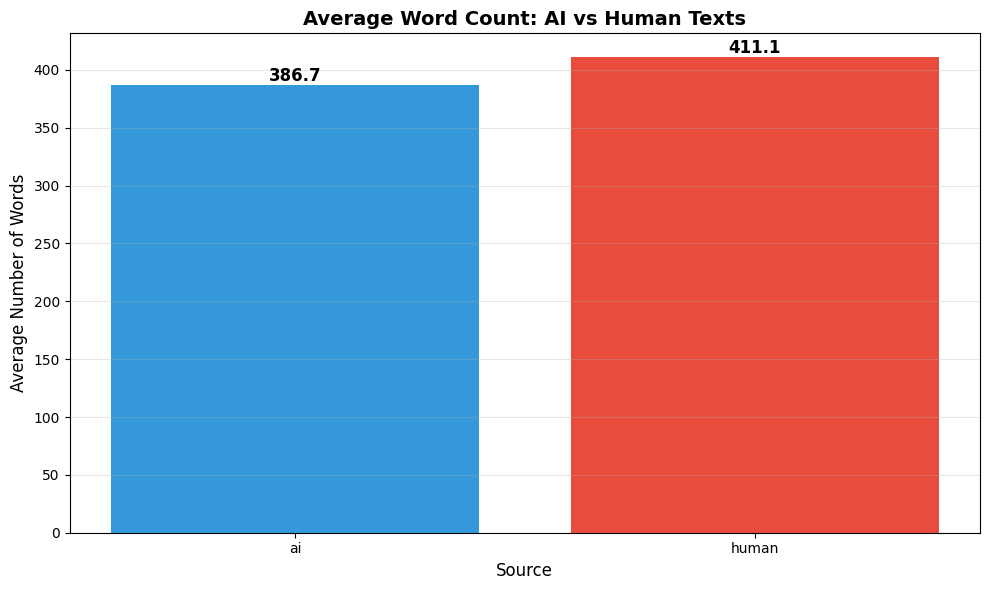

In [ ]:
# Compare average word count between AI and human texts
sample_df['word_count'] = sample_df['text'].str.split().str.len()
avg_words = sample_df.groupby('source')['word_count'].mean()

print("Average word counts:")
print(avg_words)

plt.figure(figsize=(10, 6))
bars = plt.bar(avg_words.index, avg_words.values, color=['#3498db', '#e74c3c'])

for i, (idx, val) in enumerate(avg_words.items()):
    plt.text(i, val, f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Source', fontsize=12)
plt.ylabel('Average Number of Words', fontsize=12)
plt.title('Average Word Count: AI vs Human Texts', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('avg_word_count.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Input:  text (str) - raw text string
# Output: list of lowercase word tokens

def clean_and_tokenize(text):
    # Tokenizes text into lowercase words, letters only
    return re.findall(r'\b[a-zA-Z]+\b', text.lower())

In [ ]:
# Input:  text (str) - raw text string
# Output: list of non-empty sentence strings

def get_sentences(text):
    # Splits text into sentences on punctuation terminators, removing empty results.
    sentences = re.split(r'[.!?]+', text)
    return [s.strip() for s in sentences if s.strip()]

In [ ]:
# Input:  text (str) - raw text string
# Output: list of non-empty paragraph strings

def get_paragraphs(text):
    # Splits text into paragraphs on blank lines, removing empty results.
    return [p.strip() for p in re.split(r'\n\s*\n', text) if p.strip()]

In [ ]:
# Input:  text (str) - raw text string
# Output: dict of lexical features (word count, avg word length, TTR, etc.)

def extract_lexical_features(text):
    # Computes character, word, and sentence-level statistics to capture lexical features.
    features = {}

    # Character count
    features['nchar'] = len(text)

    # Word tokenization
    words = clean_and_tokenize(text)
    features['word_count'] = len(words)

    # Average word length
    if words:
        features['avg_word_length'] = np.mean([len(word) for word in words])
    else:
        features['avg_word_length'] = 0

    # Type-Token Ratio (vocabulary richness)
    if words:
        features['type_token_ratio'] = len(set(words)) / len(words)
    else:
        features['type_token_ratio'] = 0

    # Short word ratio (words <= 3 characters)
    if words:
        short_words = sum(1 for word in words if len(word) <= 3)
        features['short_word_ratio'] = short_words / len(words)
    else:
        features['short_word_ratio'] = 0

    # Long word ratio (words >= 7 characters)
    if words:
        long_words = sum(1 for word in words if len(word) >= 7)
        features['long_word_ratio'] = long_words / len(words)
    else:
        features['long_word_ratio'] = 0

    # Sentence statistics
    sentences = get_sentences(text)
    features['sentence_count'] = len(sentences)

    if sentences:
        features['avg_sentence_length'] = len(words) / len(sentences)
    else:
        features['avg_sentence_length'] = 0

    return features

In [ ]:
# Input:  text (str) - raw text string
# Output: dict of punctuation frequency features normalized by text length and sentence count

def extract_punctuation_features(text):
    # Computes per-character and per-sentence punctuation rates to capture punctuation features.
    features = {}

    text_length = len(text) if len(text) > 0 else 1
    sentences = get_sentences(text)
    sentence_count = len(sentences) if len(sentences) > 0 else 1

    features['period_freq'] = text.count('.') / text_length
    features['comma_freq'] = text.count(',') / text_length
    features['question_mark_freq'] = text.count('?') / text_length
    features['exclamation_freq'] = text.count('!') / text_length
    features['semicolon_freq'] = text.count(';') / text_length
    features['colon_freq'] = text.count(':') / text_length
    features['dash_freq'] = text.count('-') / text_length
    features['quote_freq'] = (text.count('"') + text.count('"') + text.count('"')) / text_length
    features['apostrophe_freq'] = (text.count("'") + text.count(''') + text.count(''')) / text_length
    features['parenthesis_freq'] = (text.count('(') + text.count(')')) / text_length
    features['ellipsis_freq'] = text.count('...') / text_length

    punct_count = len(re.findall(r'[.,!?;:\-\"\'\(\)\[\]\{\}]', text))
    features['total_punctuation_ratio'] = punct_count / text_length

    features['comma_per_sentence'] = text.count(',') / sentence_count
    features['question_ratio'] = text.count('?') / sentence_count
    features['exclamation_ratio'] = text.count('!') / sentence_count

    return features

In [ ]:
# Input:  text (str) - raw text string
# Output: dict of stylometric features (casing, digits, paragraphs, contractions, etc.)

def extract_stylometric_features(text):
    # Computes character-level, word-level, and structural style signals to capture writing patterns.
    features = {}

    text_length = len(text) if len(text) > 0 else 1
    words = clean_and_tokenize(text)
    word_count = len(words) if len(words) > 0 else 1
    paragraphs = get_paragraphs(text)
    sentences = get_sentences(text)

    features['uppercase_ratio'] = sum(1 for c in text if c.isupper()) / text_length
    features['digit_ratio'] = sum(1 for c in text if c.isdigit()) / text_length
    features['whitespace_ratio'] = sum(1 for c in text if c.isspace()) / text_length

    features['paragraph_count'] = len(paragraphs)
    features['avg_word_per_paragraph'] = len(words) / len(paragraphs) if paragraphs else 0

    if words:
        word_counts = Counter(words)
        repeated_words = sum(1 for count in word_counts.values() if count >= 3)
        features['repeated_word_ratio'] = repeated_words / len(set(words)) if len(set(words)) > 0 else 0
    else:
        features['repeated_word_ratio'] = 0

    features['capital_word_ratio'] = len(re.findall(r'\b[A-Z][a-z]*\b', text)) / word_count
    features['all_caps_word_ratio'] = len(re.findall(r'\b[A-Z]{2,}\b', text)) / word_count
    features['contraction_freq'] = len(re.findall(r"\w+n't|\w+'ll|\w+'ve|\w+'re|\w+'d|\w+'m|'s\b", text.lower())) / word_count

    if sentences:
        sentence_lengths = [len(s) for s in sentences]
        features['avg_chars_per_sentence'] = np.mean(sentence_lengths)
        features['sentence_length_std'] = np.std(sentence_lengths) if len(sentence_lengths) > 1 else 0
    else:
        features['avg_chars_per_sentence'] = 0
        features['sentence_length_std'] = 0

    return features

In [ ]:
# Input:  text (str) - raw text string
# Output: dict of all lexical, punctuation, and stylometric features combined

def extract_all_features(text):
    # Aggregates all feature extractors into a single feature vector for a given text.
    features = {}
    features.update(extract_lexical_features(text))
    features.update(extract_punctuation_features(text))
    features.update(extract_stylometric_features(text))
    return features

In [ ]:
# Input:  df (DataFrame) - must contain 'text', 'id', and 'source' columns
# Output: DataFrame with all extracted features plus 'id' and 'source' columns

def create_feature_dataframe(df):
    # Applies extract_all_features to each row and returns a structured feature matrix.
    all_features = []

    for idx, row in df.iterrows():
        if idx % 100 == 0:
            print(f"Processing row {idx}/{len(df)}")

        features = extract_all_features(str(row['text']))
        features['id'] = row['id']
        features['source'] = row['source']
        all_features.append(features)

    features_df = pd.DataFrame(all_features)
    cols = ['id', 'source'] + [col for col in features_df.columns if col not in ['id', 'source']]
    features_df = features_df[cols]

    print(f"Shape: {features_df.shape}")
    print(f"Total features: {features_df.shape[1] - 2}")

    return features_df

In [ ]:
# Assign a unique ID to each sample using its index
sample_df['id'] = sample_df.index

# Extract all linguistic/stylistic features from the text samples into a structured DataFrame
features_df = create_feature_dataframe(sample_df)

Processing row 0/70000
Processing row 100/70000
Processing row 200/70000
Processing row 300/70000
Processing row 400/70000
Processing row 500/70000
Processing row 600/70000
Processing row 700/70000
Processing row 800/70000
Processing row 900/70000
Processing row 1000/70000
Processing row 1100/70000
Processing row 1200/70000
Processing row 1300/70000
Processing row 1400/70000
Processing row 1500/70000
Processing row 1600/70000
Processing row 1700/70000
Processing row 1800/70000
Processing row 1900/70000
Processing row 2000/70000
Processing row 2100/70000
Processing row 2200/70000
Processing row 2300/70000
Processing row 2400/70000
Processing row 2500/70000
Processing row 2600/70000
Processing row 2700/70000
Processing row 2800/70000
Processing row 2900/70000
Processing row 3000/70000
Processing row 3100/70000
Processing row 3200/70000
Processing row 3300/70000
Processing row 3400/70000
Processing row 3500/70000
Processing row 3600/70000
Processing row 3700/70000
Processing row 3800/7000

In [ ]:
# Input:  features_df (DataFrame) - feature matrix with 'source' column (human/ai)
# Output: saves and displays boxplot comparison figures per feature category

def plot_feature_comparison_grouped(features_df):
    # Plots side-by-side boxplots for each feature grouped by category, with dark background styling.
    plt.style.use('dark_background')

    feature_cols = [col for col in features_df.columns if col not in ['id', 'source']]

    lexical_features = ['nchar', 'word_count', 'avg_word_length', 'type_token_ratio',
                        'short_word_ratio', 'long_word_ratio', 'sentence_count', 'avg_sentence_length']

    punctuation_features = ['period_freq', 'comma_freq', 'question_mark_freq', 'exclamation_freq',
                            'semicolon_freq', 'colon_freq', 'dash_freq', 'quote_freq',
                            'apostrophe_freq', 'parenthesis_freq', 'ellipsis_freq',
                            'total_punctuation_ratio', 'comma_per_sentence', 'question_ratio', 'exclamation_ratio']

    stylometric_features = [col for col in feature_cols if col not in lexical_features
                            and col not in punctuation_features]

    categories = {
        'Lexical Features': lexical_features,
        'Punctuation Features': punctuation_features,
        'Stylometric Features': stylometric_features
    }

    for category_name, features in categories.items():
        n_cols = 3
        n_rows = int(np.ceil(len(features) / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 8 * n_rows))
        fig.patch.set_facecolor('black')

        if n_rows == 1:
            axes = axes.reshape(1, -1)
        axes = axes.flatten()

        for idx, feature in enumerate(features):
            ax = axes[idx]
            ax.set_facecolor('#1a1a1a')

            human_data = features_df[features_df['source'] == 'human'][feature].dropna()
            ai_data = features_df[features_df['source'] == 'ai'][feature].dropna()

            bp = ax.boxplot([human_data, ai_data], labels=['Human', 'AI'], patch_artist=True,
                            boxprops=dict(linewidth=2.5),
                            whiskerprops=dict(linewidth=2.5, color='white'),
                            capprops=dict(linewidth=2.5, color='white'),
                            medianprops=dict(linewidth=3.5, color='yellow'))

            bp['boxes'][0].set_facecolor('#00CED1')
            bp['boxes'][0].set_alpha(0.7)
            bp['boxes'][1].set_facecolor('#FF6347')
            bp['boxes'][1].set_alpha(0.7)

            ax.set_title(feature, fontsize=18, fontweight='bold', color='white', pad=15)
            ax.set_ylabel('Value', fontsize=16, color='white', fontweight='bold')
            ax.set_xlabel('Source', fontsize=16, color='white', fontweight='bold')
            ax.tick_params(colors='white', labelsize=14, width=2, length=6)
            ax.grid(True, alpha=0.2, color='gray', linewidth=1.5)
            ax.set_xticklabels(['Human', 'AI'], fontsize=15, fontweight='bold')

            ax.plot([1], [human_data.mean()], 'D', color='cyan', markersize=12,
                    markeredgecolor='white', markeredgewidth=2.5)
            ax.plot([2], [ai_data.mean()], 'D', color='red', markersize=12,
                    markeredgecolor='white', markeredgewidth=2.5)

        for idx in range(len(features), len(axes)):
            fig.delaxes(axes[idx])

        plt.suptitle(category_name, fontsize=24, fontweight='bold', color='white', y=1.00)
        plt.tight_layout()

        filename = f"{category_name.lower().replace(' ', '_')}_comparison.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='black', edgecolor='none')
        plt.show()

    plt.style.use('default')

In [ ]:
# Input:  features_df (DataFrame) - feature matrix with 'source' column (human/ai)
# Output: DataFrame of per-feature statistics sorted by absolute mean difference

def print_feature_statistics(features_df):
    # Compares human vs. AI feature distributions and ranks by most discriminative features.
    feature_cols = [col for col in features_df.columns if col not in ['id', 'source']]

    comparison_data = []
    for feature in feature_cols:
        human_data = features_df[features_df['source'] == 'human'][feature].dropna()
        ai_data = features_df[features_df['source'] == 'ai'][feature].dropna()

        comparison_data.append({
            'Feature': feature,
            'Human_Mean': human_data.mean(),
            'AI_Mean': ai_data.mean(),
            'Human_Std': human_data.std(),
            'AI_Std': ai_data.std(),
            'Difference': abs(human_data.mean() - ai_data.mean()),
            'Diff_Percentage': abs(human_data.mean() - ai_data.mean()) / (human_data.mean() + 1e-10) * 100
        })

    comparison_df = pd.DataFrame(comparison_data).sort_values('Difference', ascending=False)

    print("TOP 10 MOST DISCRIMINATIVE FEATURES (by absolute difference):")
    for idx, row in comparison_df.head(10).iterrows():
        print(f"{row['Feature']:30s} | Human: {row['Human_Mean']:8.4f} | AI: {row['AI_Mean']:8.4f} | Diff: {row['Difference']:8.4f}")

    return comparison_df

In [ ]:
print_feature_statistics(features_df)

TOP 10 MOST DISCRIMINATIVE FEATURES (by absolute difference):
nchar                          | Human: 2505.4657 | AI: 2218.8757 | Diff: 286.5900
avg_chars_per_sentence         | Human:  85.8413 | AI: 115.0244 | Diff:  29.1831
word_count                     | Human: 406.7550 | AI: 390.0043 | Diff:  16.7507
sentence_count                 | Human:  28.8006 | AI:  20.8306 | Diff:   7.9701
sentence_length_std            | Human:  52.5363 | AI:  58.3302 | Diff:   5.7939
avg_sentence_length            | Human:  15.1328 | AI:  20.1626 | Diff:   5.0298
avg_word_per_paragraph         | Human:  56.2178 | AI:  58.1371 | Diff:   1.9193
paragraph_count                | Human:  10.3235 | AI:  10.0175 | Diff:   0.3059
comma_per_sentence             | Human:   0.7999 | AI:   1.0439 | Diff:   0.2441
type_token_ratio               | Human:   0.5843 | AI:   0.5242 | Diff:   0.0601


,Feature,Human_Mean,AI_Mean,Human_Std,AI_Std,Difference,Diff_Percentage
0,nchar,2505.465743,2218.875743,4928.913467,1686.440346,286.590000,11.438592
32,avg_chars_per_sentence,85.841308,115.024419,62.500663,94.141949,29.183111,33.996583
1,word_count,406.755029,390.004286,670.439194,300.075900,16.750743,4.118140
6,sentence_count,28.800629,20.830571,56.236454,17.173114,7.970057,27.673206
33,sentence_length_std,52.536326,58.330189,42.889077,60.765634,5.793863,11.028300
7,avg_sentence_length,15.132819,20.162612,10.016706,13.238825,5.029793,33.237647
27,avg_word_per_paragraph,56.217834,58.137107,61.762318,63.573500,1.919273,3.413993
26,paragraph_count,10.323486,10.017543,14.690893,10.596371,0.305943,2.963562
20,comma_per_sentence,0.799887,1.043947,1.001910,1.332057,0.244060,30.511853
3,type_token_ratio,0.584327,0.524241,0.126989,0.160283,0.060086,10.282881


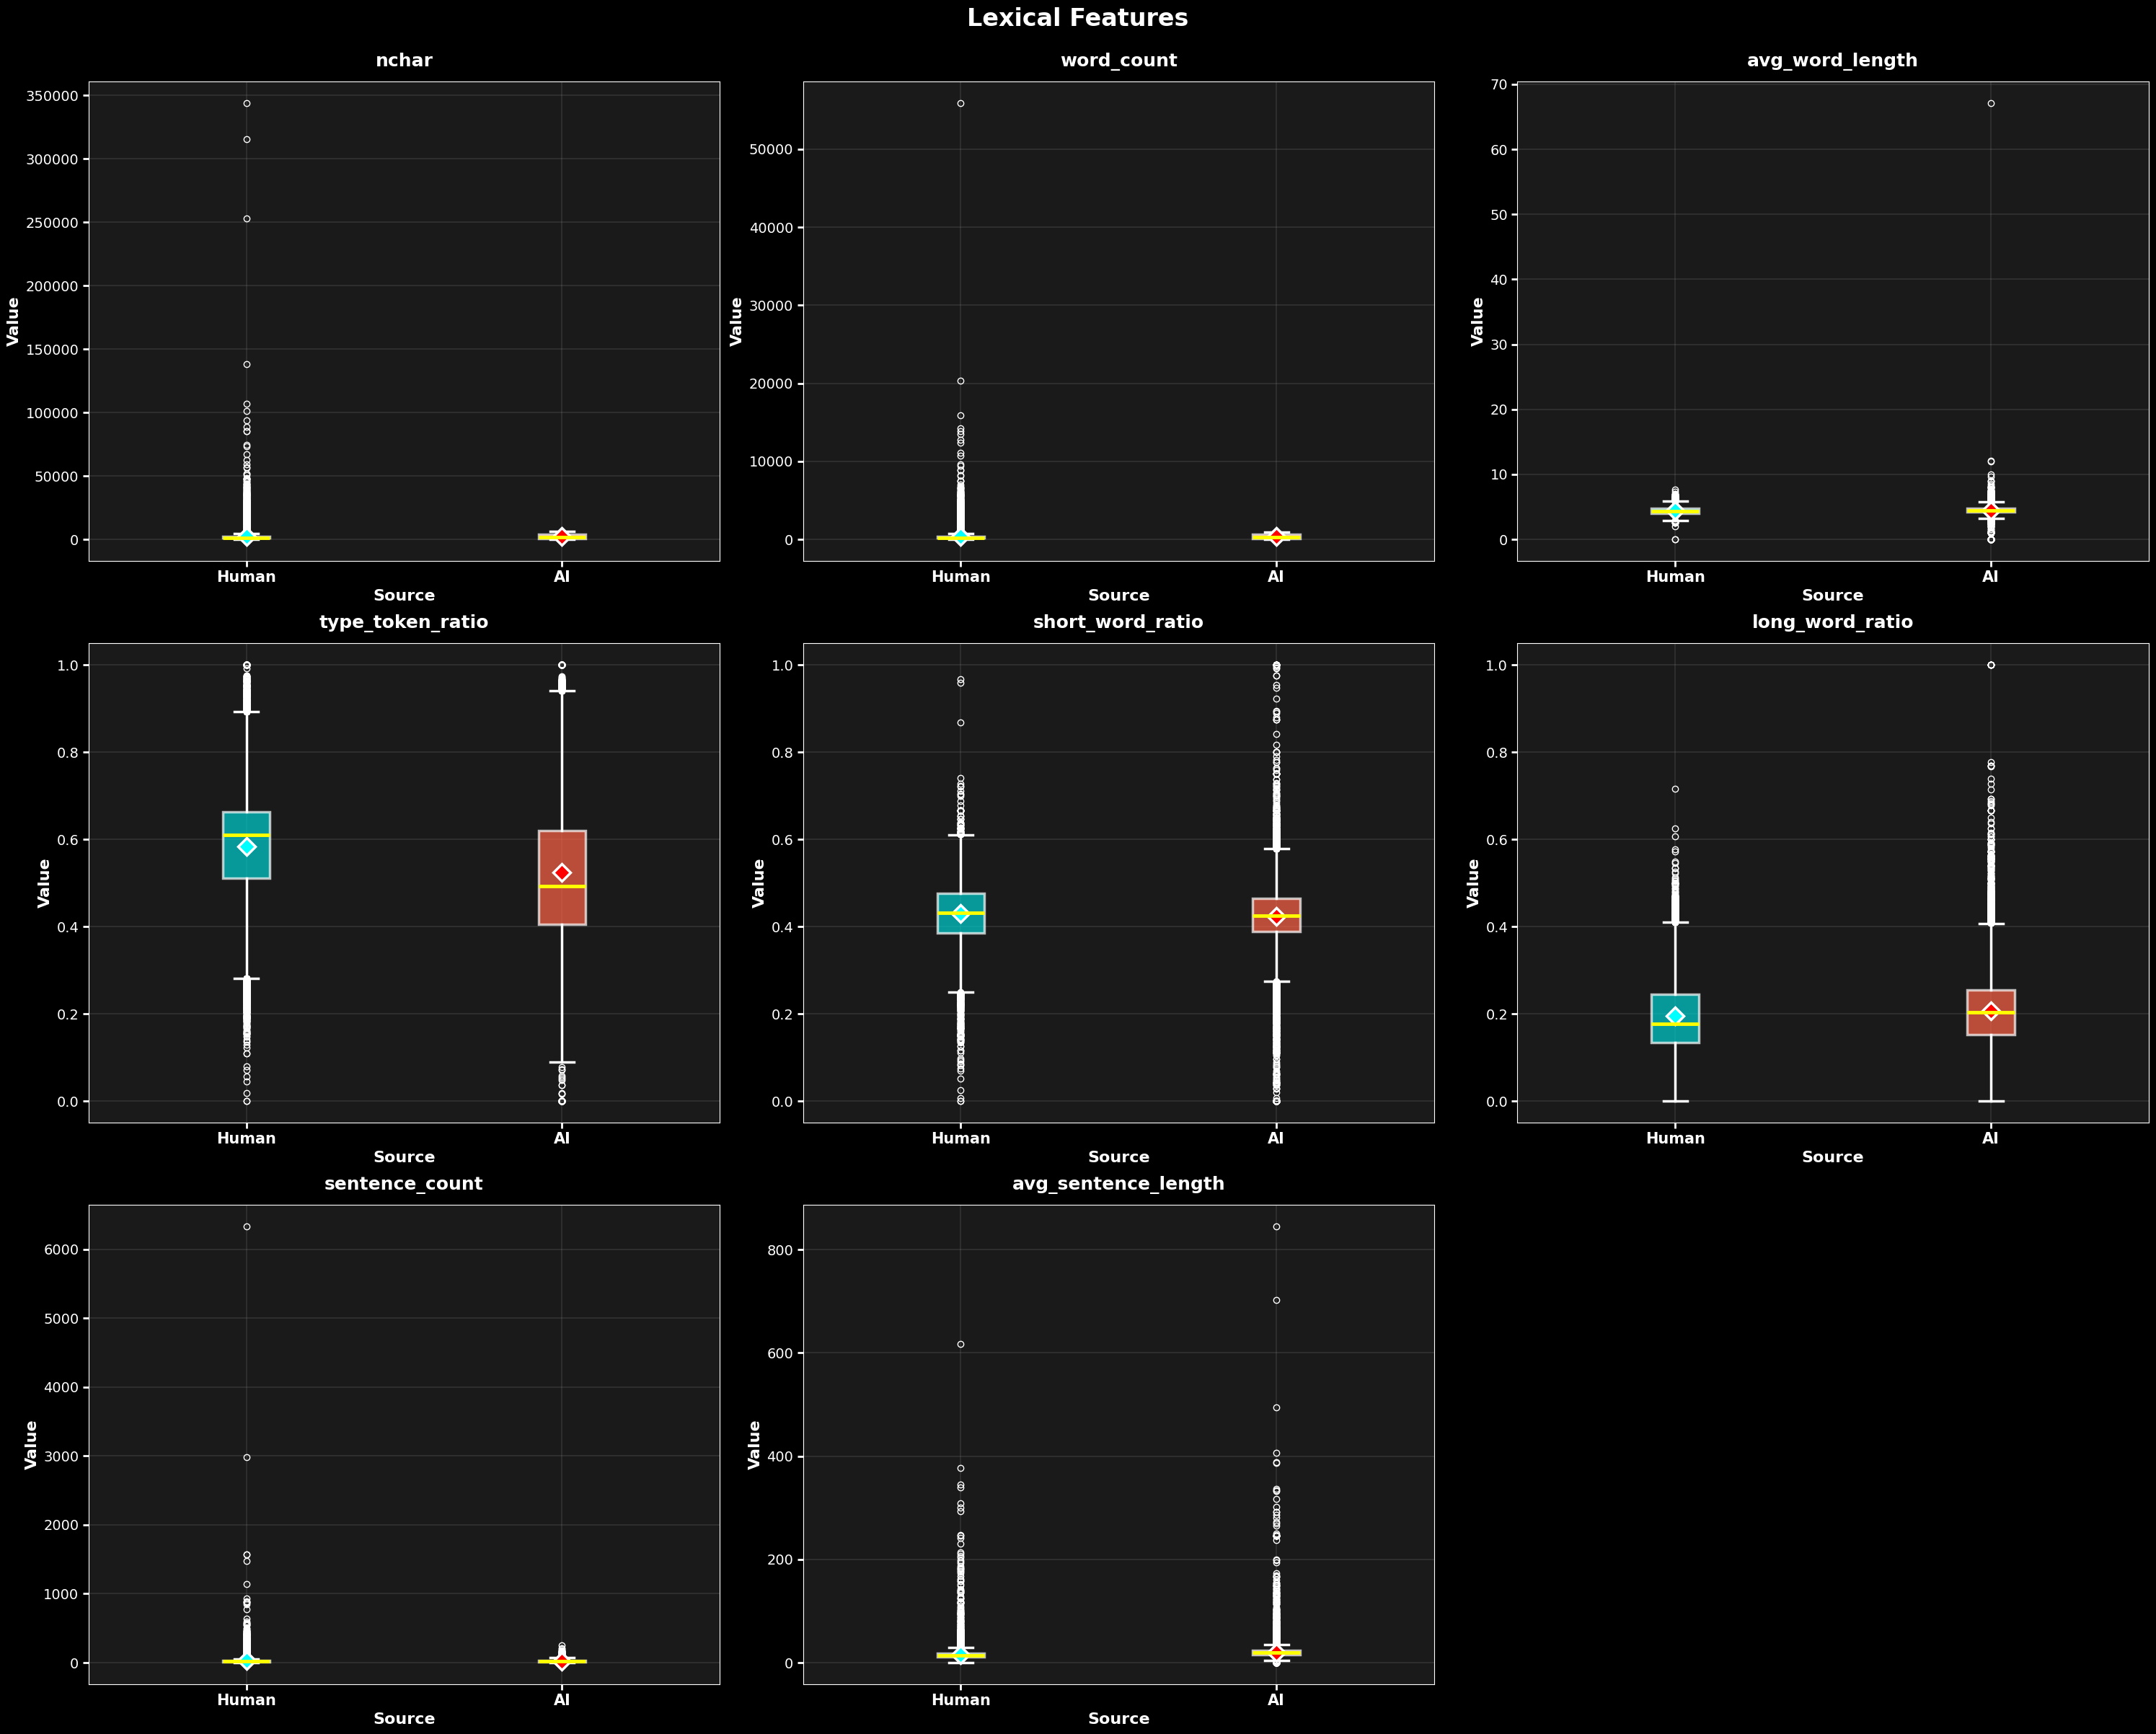

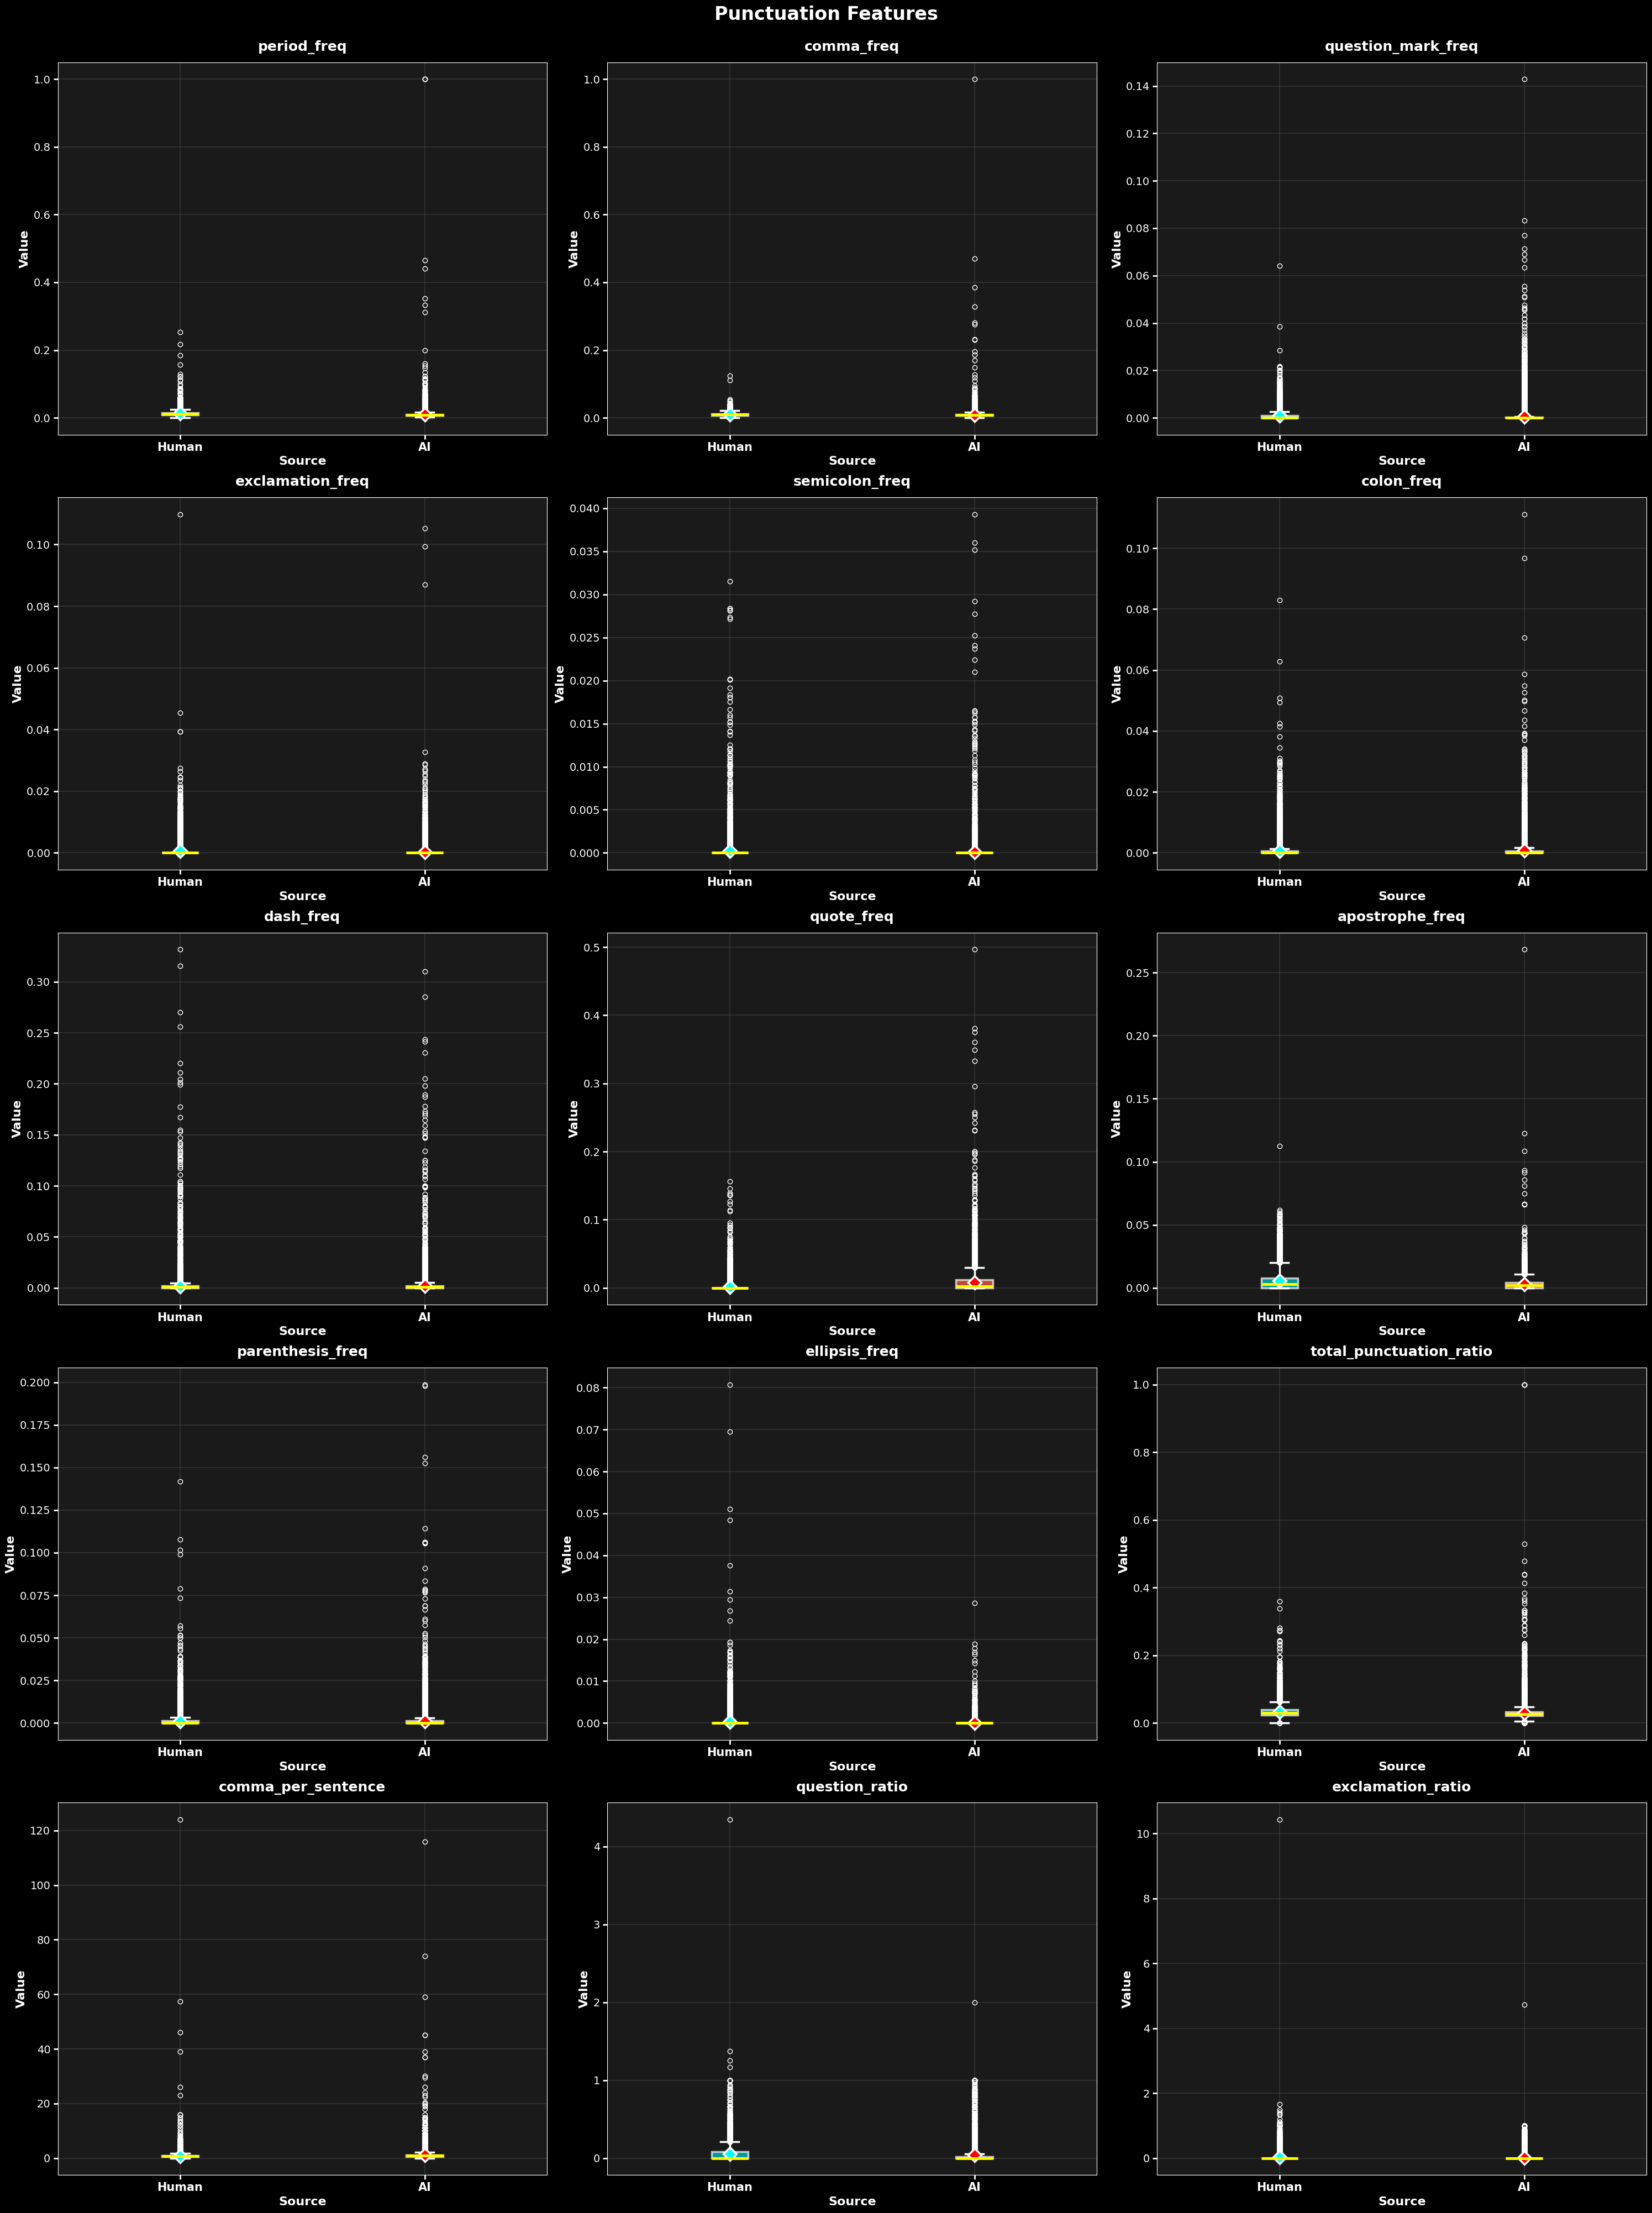

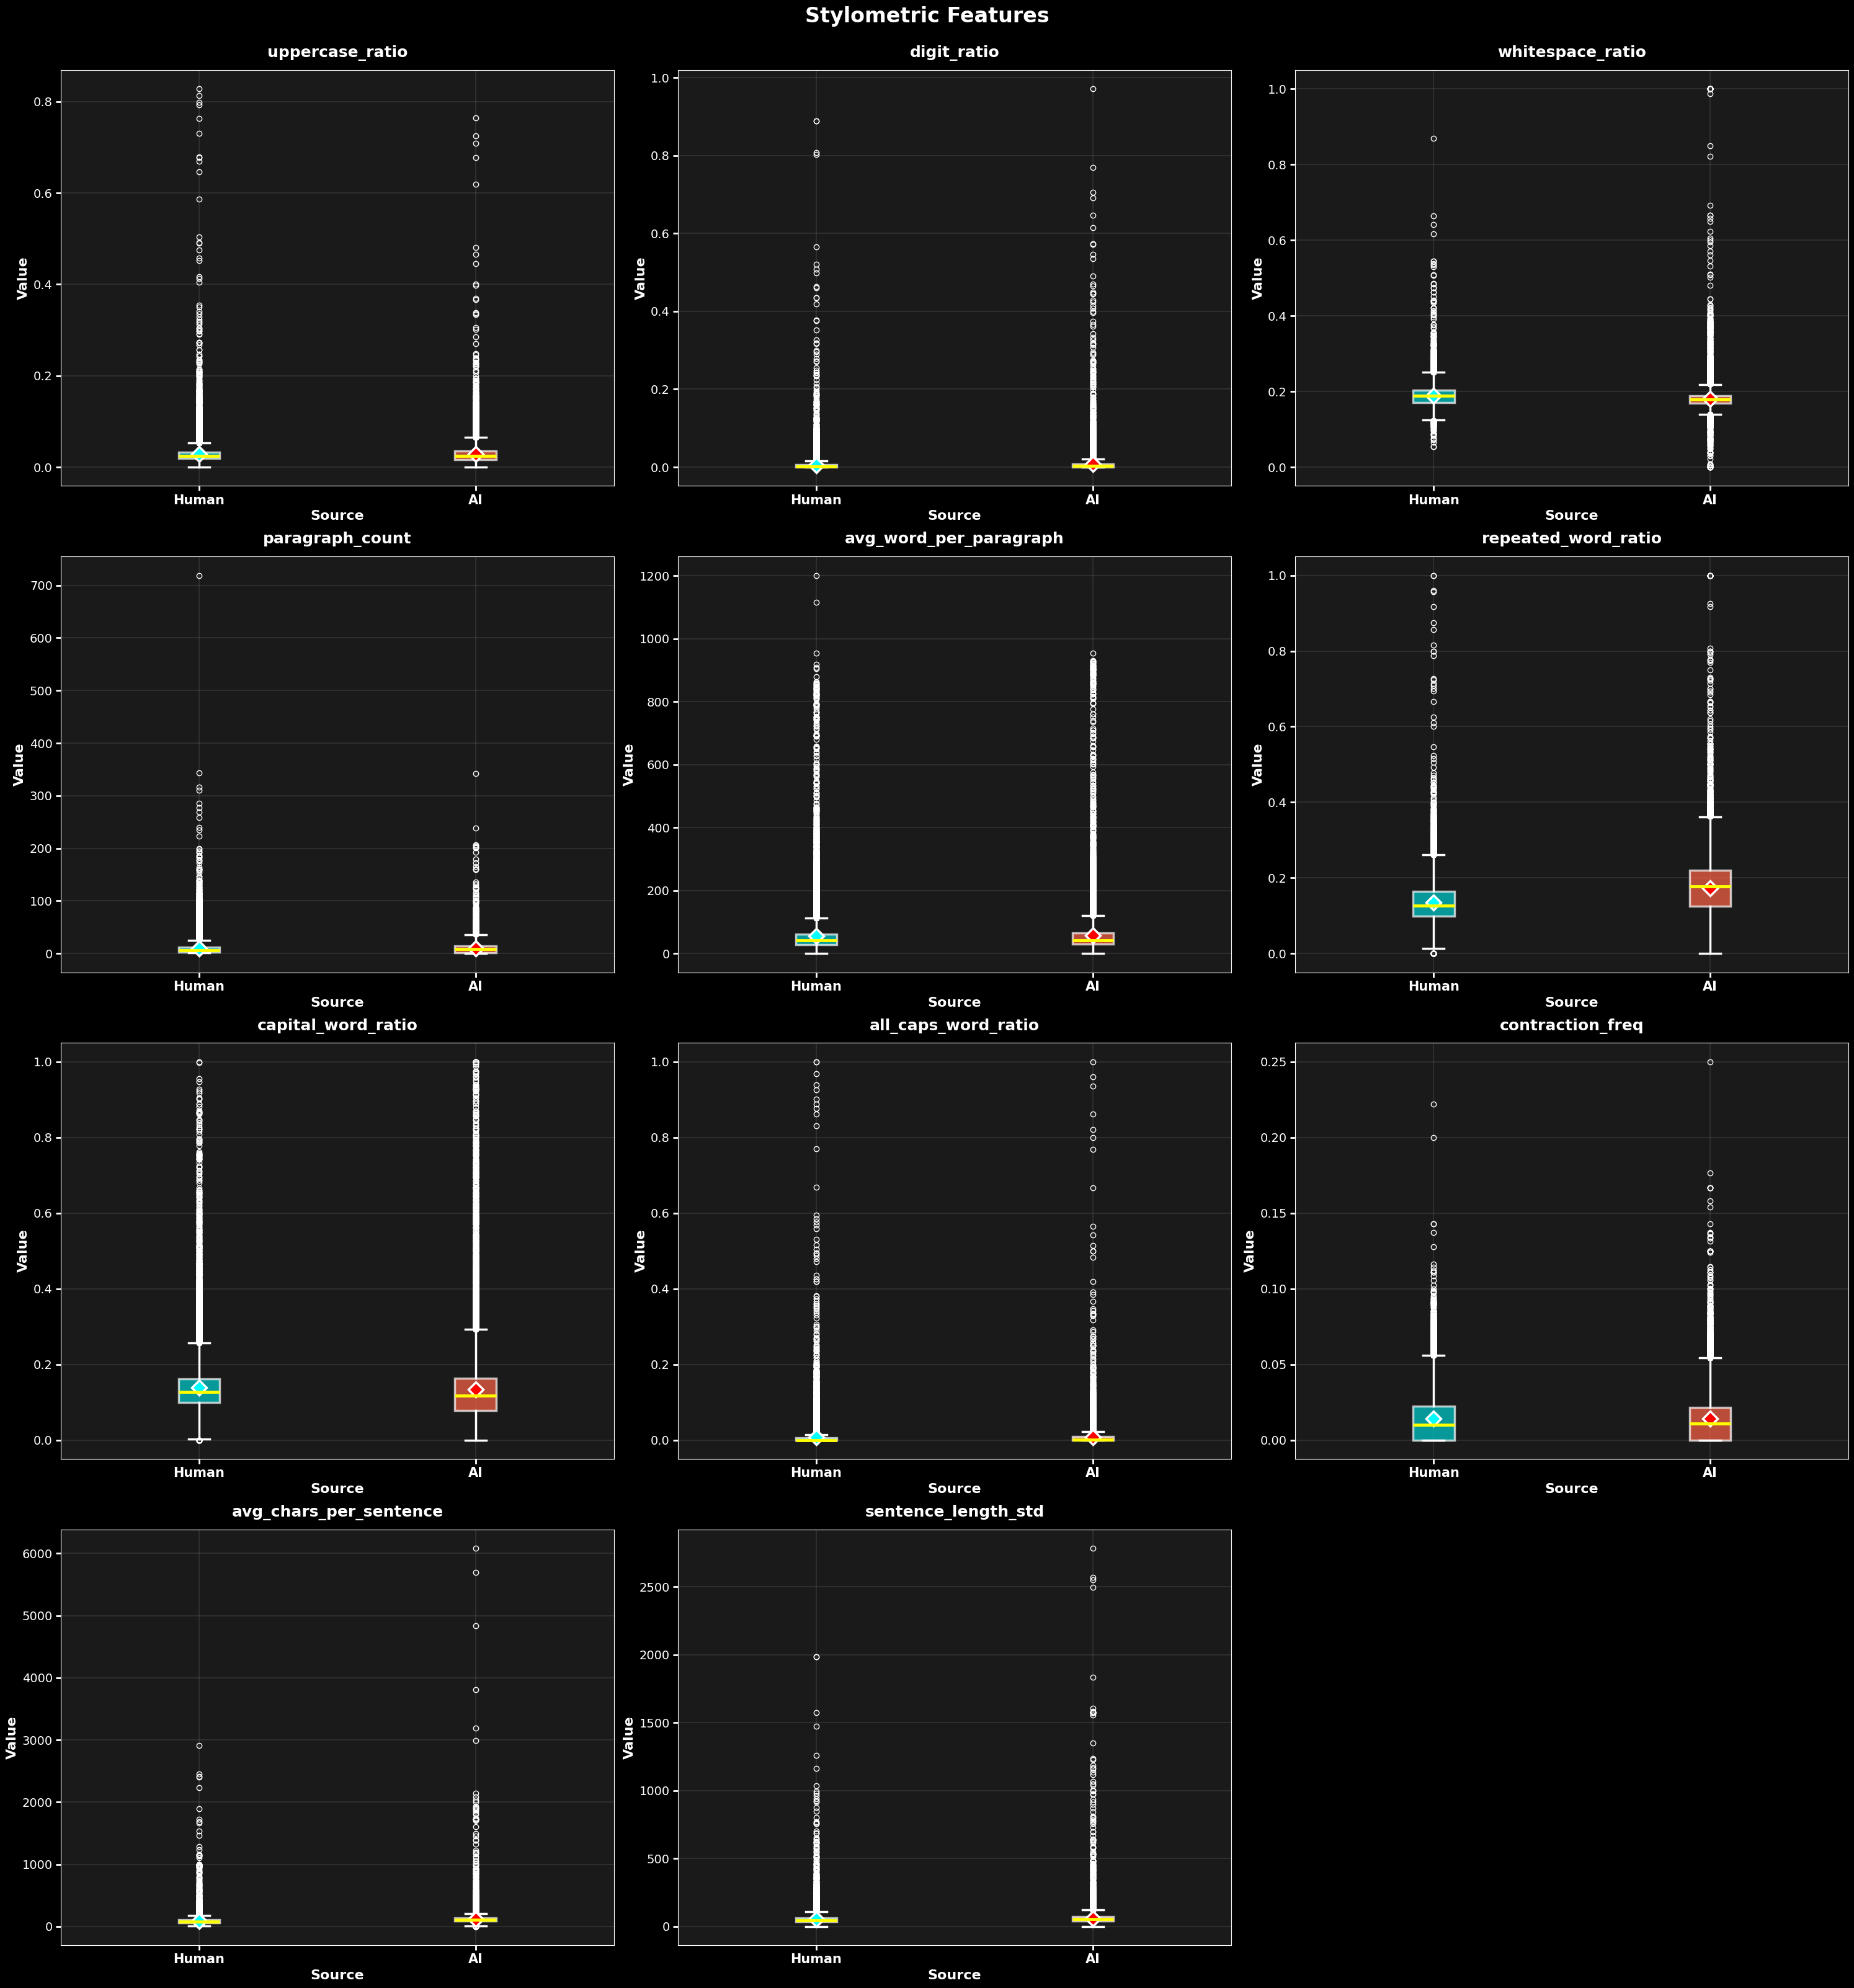

In [ ]:
plot_feature_comparison_grouped(features_df)

In [ ]:
# Input:  features_df (DataFrame) - feature matrix with 'source' column (human/ai)
# Output: tuple of (pca, scaler, X_pca) - fitted PCA, scaler, and 2D projected data

def plot_pca_2d(features_df):
    # Standardizes features, applies 2D PCA, and plots a dark-themed scatter of human vs. AI texts.
    feature_cols = [col for col in features_df.columns if col not in ['id', 'source']]
    X = features_df[feature_cols].values
    y = features_df['source'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('black')
    ax.set_facecolor('#1a1a1a')

    ax.scatter(X_pca[y == 'human', 0], X_pca[y == 'human', 1],
               c='#00CED1', s=80, alpha=0.7, edgecolors='white',
               linewidth=1.5, label='Human', marker='o')

    ax.scatter(X_pca[y == 'ai', 0], X_pca[y == 'ai', 1],
               c='#FF00FF', s=80, alpha=0.7, edgecolors='white',
               linewidth=1.5, label='AI', marker='s')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)',
                  fontsize=12, fontweight='bold', color='white')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)',
                  fontsize=12, fontweight='bold', color='white')
    ax.set_title('PCA: Human vs AI Text Classification',
                 fontsize=14, fontweight='bold', color='white', pad=12)

    ax.legend(fontsize=11, loc='best', framealpha=0.9, edgecolor='white',
              fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, color='gray', linewidth=1.5)
    ax.tick_params(colors='white', labelsize=10, width=2, length=6)

    total_variance = sum(pca.explained_variance_ratio_[:2])
    ax.text(0.02, 0.98, f'Total Variance: {total_variance*100:.2f}%',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='#333333', alpha=0.8, edgecolor='white'),
            color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig('pca_2d_visualization.png', dpi=300, bbox_inches='tight',
                facecolor='black', edgecolor='none')
    plt.show()
    plt.style.use('default')

    return pca, scaler, X_pca


In [ ]:
# Input:  features_df (DataFrame) - feature matrix with 'source' column (human/ai)
    #         n_components (int) - number of principal components to analyze (default: 2)
    # Output: prints top 10 contributing features per principal component

def print_top_features_per_component(features_df, n_components=2):
    # Fits PCA and ranks features by their absolute loading magnitude per component.
    feature_cols = [col for col in features_df.columns if col not in ['id', 'source']]
    X_scaled = StandardScaler().fit_transform(features_df[feature_cols].values)

    pca = PCA(n_components=n_components)
    pca.fit(X_scaled)
    loadings = pca.components_

    for i in range(n_components):
        print(f"\nPC{i+1} (Explains {pca.explained_variance_ratio_[i]*100:.2f}% variance)")
        top_indices = np.argsort(np.abs(loadings[i]))[-10:][::-1]
        for idx in top_indices:
            print(f"  {feature_cols[idx]:30s} : {loadings[i][idx]:7.4f}")

In [ ]:
print_top_features_per_component(features_df, n_components=3)


PC1 (Explains 15.53% variance)
  word_count                     :  0.3060
  nchar                          :  0.3025
  long_word_ratio                :  0.2860
  avg_word_length                :  0.2755
  paragraph_count                :  0.2733
  type_token_ratio               : -0.2504
  sentence_count                 :  0.2385
  short_word_ratio               : -0.2221
  repeated_word_ratio            :  0.2114
  apostrophe_freq                : -0.2053

PC2 (Explains 10.40% variance)
  sentence_count                 :  0.3317
  paragraph_count                :  0.3116
  word_count                     :  0.3029
  nchar                          :  0.3002
  type_token_ratio               : -0.2544
  repeated_word_ratio            :  0.2387
  apostrophe_freq                :  0.2244
  total_punctuation_ratio        :  0.2230
  contraction_freq               :  0.2117
  avg_word_length                : -0.2062

PC3 (Explains 8.40% variance)
  uppercase_ratio                :  0.4347
  

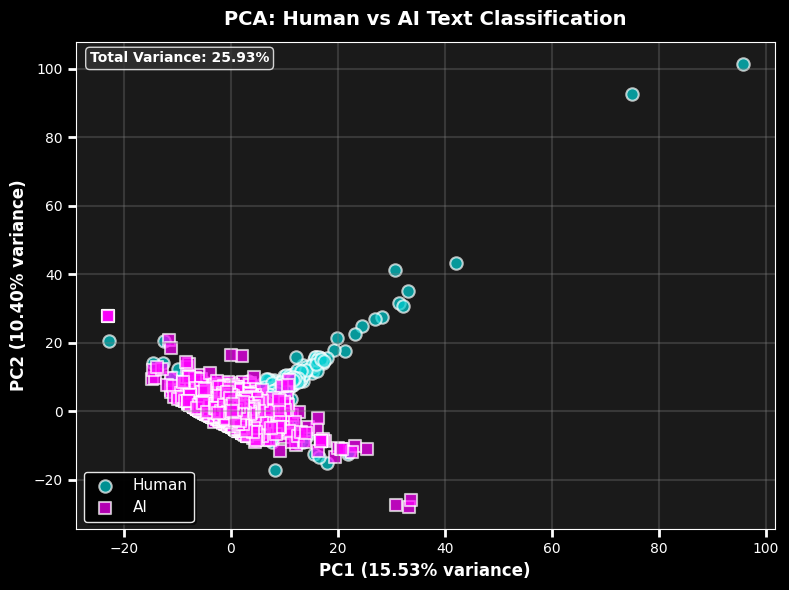

In [ ]:
pca_model, scaler, X_pca = plot_pca_2d(features_df)

In [ ]:
features_df.head()

,id,source,nchar,word_count,avg_word_length,type_token_ratio,short_word_ratio,long_word_ratio,sentence_count,avg_sentence_length,...,digit_ratio,whitespace_ratio,paragraph_count,avg_word_per_paragraph,repeated_word_ratio,capital_word_ratio,all_caps_word_ratio,contraction_freq,avg_chars_per_sentence,sentence_length_std
0,0,ai,469,56,7.053571,0.642857,0.125000,0.678571,2,28.000000,...,0.000000,0.121535,1,56.000000,0.027778,0.642857,0.000000,0.000000,232.000000,30.000000
1,1,ai,3515,569,4.841828,0.448155,0.323374,0.242531,32,17.781250,...,0.012802,0.159602,10,56.900000,0.176471,0.224956,0.010545,0.015817,107.937500,79.038732
2,2,ai,4439,864,3.966435,0.369213,0.482639,0.138889,43,20.093023,...,0.002703,0.195089,16,54.000000,0.250784,0.099537,0.009259,0.023148,101.116279,58.328743
3,3,ai,157,18,6.555556,0.833333,0.000000,0.555556,1,18.000000,...,0.031847,0.184713,1,18.000000,0.066667,0.000000,0.000000,0.000000,156.000000,0.000000
4,4,human,1324,229,3.480349,0.515284,0.550218,0.082969,35,6.542857,...,0.001511,0.240181,23,9.956522,0.186441,0.218341,0.000000,0.078603,36.114286,20.787045


In [ ]:
features_df.to_csv('data1.csv', encoding='utf-8')

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
import time

warnings.filterwarnings('ignore')

In [ ]:
# Prints a formatted key-value row with dot leaders for aligned console output
def mrow(name, value, width=34):
    dots = "." * max(1, width - len(str(name)))
    print("  " + str(name) + dots + " " + str(value))

In [ ]:
# Prepare feature matrix and labels, excluding metadata columns
feature_columns = [col for col in features_df.columns if col not in ['id', 'source', 'Unnamed: 0']]

X = features_df[feature_columns].values
y = features_df['source'].values

print(feature_columns)
print(features_df.isnull().sum().sum())

['nchar', 'word_count', 'avg_word_length', 'type_token_ratio', 'short_word_ratio', 'long_word_ratio', 'sentence_count', 'avg_sentence_length', 'period_freq', 'comma_freq', 'question_mark_freq', 'exclamation_freq', 'semicolon_freq', 'colon_freq', 'dash_freq', 'quote_freq', 'apostrophe_freq', 'parenthesis_freq', 'ellipsis_freq', 'total_punctuation_ratio', 'comma_per_sentence', 'question_ratio', 'exclamation_ratio', 'uppercase_ratio', 'digit_ratio', 'whitespace_ratio', 'paragraph_count', 'avg_word_per_paragraph', 'repeated_word_ratio', 'capital_word_ratio', 'all_caps_word_ratio', 'contraction_freq', 'avg_chars_per_sentence', 'sentence_length_std']
0


In [ ]:
# Shuffle dataset
sample_df = sample_df.sample(frac=1, random_state=42).reset_index(drop=True)

# First split: Train (70%) and Temp (30%)
train_split, temp_split = train_test_split(
    sample_df,
    test_size=0.30,
    stratify=sample_df['source'],
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
val_split, test_split = train_test_split(
    temp_split,
    test_size=0.50,
    stratify=temp_split['source'],
    random_state=42
)

# Reset indices
train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)
test_split  = test_split.reset_index(drop=True)

# Save splits
train_split.to_parquet('split_train.parquet', index=False)
val_split.to_parquet('split_val.parquet',     index=False)
test_split.to_parquet('split_test.parquet',   index=False)

# Summary
_n = len(sample_df)

mrow("Train", "{:,}  ({:.1f}%)".format(len(train_split), len(train_split)/_n*100))
mrow("Val",   "{:,}  ({:.1f}%)".format(len(val_split),   len(val_split)/_n*100))
mrow("Test",  "{:,}  ({:.1f}%)".format(len(test_split),  len(test_split)/_n*100))

  Train............................. 49,000  (70.0%)
  Val............................... 10,500  (15.0%)
  Test.............................. 10,500  (15.0%)


In [ ]:
# Verify class balance
for name, split in [('Training', train_split), ('Validation', val_split), ('Test', test_split)]:
    print(f"\n{name} set distribution:")
    unique, counts = np.unique(split['source'], return_counts=True)
    for label, count in zip(unique, counts):
        mrow(label, "{:,}  ({:.1f}%)".format(count, count/len(split)*100))


Training set distribution:
  ai................................ 24,500  (50.0%)
  human............................. 24,500  (50.0%)

Validation set distribution:
  ai................................ 5,250  (50.0%)
  human............................. 5,250  (50.0%)

Test set distribution:
  ai................................ 5,250  (50.0%)
  human............................. 5,250  (50.0%)


In [ ]:
# Assign unique IDs to each split using their respective indices
train_split['id'] = train_split.index
val_split['id']   = val_split.index
test_split['id']  = test_split.index

# Extract features for each data split
train_features = create_feature_dataframe(train_split)
val_features   = create_feature_dataframe(val_split)
test_features  = create_feature_dataframe(test_split)

# Select only feature columns, excluding metadata and label columns
feature_columns = [col for col in train_features.columns if col not in ['id', 'source', 'Unnamed: 0']]

# Separate features and labels for each split
X_train = train_features[feature_columns].values
y_train = train_features['source'].values
X_val   = val_features[feature_columns].values
y_val   = val_features['source'].values
X_test  = test_features[feature_columns].values
y_test  = test_features['source'].values

# Encode class labels and summarize dataset dimensions
class_labels  = sorted(np.unique(y))
label_encoder = LabelEncoder()
y_temp        = label_encoder.fit_transform(y)

print(f"Features: {len(feature_columns)}")
print(f"Samples:  {len(X)}")
print(f"Classes:  {label_encoder.classes_} -> {label_encoder.transform(label_encoder.classes_)}")

Processing row 0/49000
Processing row 100/49000
Processing row 200/49000
Processing row 300/49000
Processing row 400/49000
Processing row 500/49000
Processing row 600/49000
Processing row 700/49000
Processing row 800/49000
Processing row 900/49000
Processing row 1000/49000
Processing row 1100/49000
Processing row 1200/49000
Processing row 1300/49000
Processing row 1400/49000
Processing row 1500/49000
Processing row 1600/49000
Processing row 1700/49000
Processing row 1800/49000
Processing row 1900/49000
Processing row 2000/49000
Processing row 2100/49000
Processing row 2200/49000
Processing row 2300/49000
Processing row 2400/49000
Processing row 2500/49000
Processing row 2600/49000
Processing row 2700/49000
Processing row 2800/49000
Processing row 2900/49000
Processing row 3000/49000
Processing row 3100/49000
Processing row 3200/49000
Processing row 3300/49000
Processing row 3400/49000
Processing row 3500/49000
Processing row 3600/49000
Processing row 3700/49000
Processing row 3800/4900

In [ ]:
# Standardize features using scaler fitted on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Features standardized using StandardScaler")

Features standardized using StandardScaler


In [ ]:
# Initialize Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print(f"Random Forest Parameters:")
print(f"  n_estimators:      {rf_model.n_estimators}")
print(f"  max_depth:         {rf_model.max_depth}")
print(f"  min_samples_split: {rf_model.min_samples_split}")
print(f"  min_samples_leaf:  {rf_model.min_samples_leaf}")

Random Forest Parameters:
  n_estimators:      100
  max_depth:         15
  min_samples_split: 5
  min_samples_leaf:  3


In [ ]:
# Train Random Forest and measure elapsed time
rf_start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
rf_train_time = time.time() - rf_start_time
print(f"Training completed in {rf_train_time:.2f} seconds")

Training completed in 21.48 seconds


In [ ]:
# Generate predictions and probability scores across all splits
rf_train_pred = rf_model.predict(X_train_scaled)
rf_val_pred = rf_model.predict(X_val_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

ai_class_index = list(rf_model.classes_).index('ai')
rf_test_proba = rf_model.predict_proba(X_test_scaled)[:, ai_class_index]

In [ ]:
# Calculate and report Random Forest performance metrics
rf_metrics = {
    'train_acc': accuracy_score(y_train, rf_train_pred),
    'val_acc': accuracy_score(y_val, rf_val_pred),
    'test_acc': accuracy_score(y_test, rf_test_pred),
    'test_precision': precision_score(y_test, rf_test_pred, pos_label='ai'),
    'test_recall': recall_score(y_test, rf_test_pred, pos_label='ai'),
    'test_f1': f1_score(y_test, rf_test_pred, pos_label='ai'),
    'test_auc': roc_auc_score((y_test == 'ai').astype(int), rf_test_proba),
    'train_time': rf_train_time
}

print(classification_report(y_test, rf_test_pred, target_names=label_encoder.classes_))# Calculate and report Random Forest performance metrics
rf_metrics = {
    'train_acc': accuracy_score(y_train, rf_train_pred),
    'val_acc': accuracy_score(y_val, rf_val_pred),
    'test_acc': accuracy_score(y_test, rf_test_pred),
    'test_precision': precision_score(y_test, rf_test_pred, pos_label='ai'),
    'test_recall': recall_score(y_test, rf_test_pred, pos_label='ai'),
    'test_f1': f1_score(y_test, rf_test_pred, pos_label='ai'),
    'test_auc': roc_auc_score((y_test == 'ai').astype(int), rf_test_proba),
    'train_time': rf_train_time
}

print(classification_report(y_test, rf_test_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

          ai       0.85      0.95      0.90      5250
       human       0.95      0.83      0.89      5250

    accuracy                           0.89     10500
   macro avg       0.90      0.89      0.89     10500
weighted avg       0.90      0.89      0.89     10500

              precision    recall  f1-score   support

          ai       0.85      0.95      0.90      5250
       human       0.95      0.83      0.89      5250

    accuracy                           0.89     10500
   macro avg       0.90      0.89      0.89     10500
weighted avg       0.90      0.89      0.89     10500



In [ ]:
# Rank features by their importance scores from the trained Random Forest
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

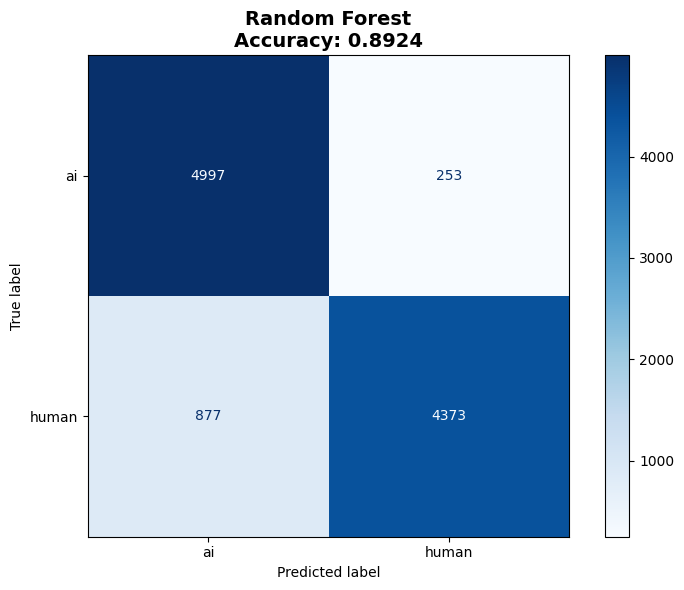

In [ ]:
# Plot and save the Random Forest confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

rf_cm = confusion_matrix(y_test, rf_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Random Forest\nAccuracy: {rf_metrics["test_acc"]:.4f}',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Input:  X_test (array), y_test (array), y_pred (array)
#         feature_columns (list), original_df (DataFrame)
# Output: DataFrame of misclassified samples

def get_misclassified(X_test, y_test, y_pred, feature_columns, original_df):
    # Extract misclassified samples
    mask = y_test != y_pred

    misclassified_df = pd.DataFrame(X_test[mask], columns=feature_columns)
    misclassified_df['text'] = original_df.iloc[np.where(mask)[0]]['text'].values
    misclassified_df['true_label'] = y_test[mask]
    misclassified_df['predicted_label'] = y_pred[mask]

    mrow("Misclassified samples", len(misclassified_df))

    misclassified_df.to_csv('rf_misclassified.csv', index=False)
    return misclassified_df

In [ ]:
# Retrieve all misclassified test samples from the Random Forest model for error analysis
rf_misclassified = get_misclassified(
    X_test_scaled,
    y_test,
    rf_test_pred,
    feature_columns,
    test_split
)

  Misclassified samples............. 1130


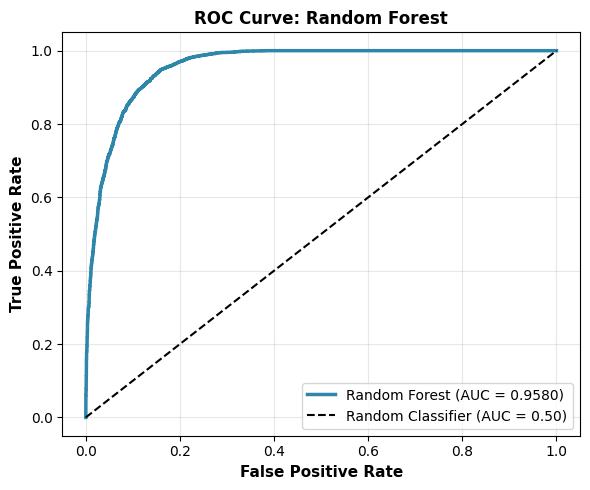

In [ ]:
# Plot the ROC curve for the Random Forest model against a random baseline
fig, ax = plt.subplots(figsize=(6, 5))

# Compute ROC curve values using binary labels (ai = positive class)
rf_fpr, rf_tpr, _ = roc_curve((y_test == 'ai').astype(int), rf_test_proba)

# Plot the Random Forest ROC curve
ax.plot(
    rf_fpr,
    rf_tpr,
    color='#2E86AB',
    lw=2.5,
    label=f'Random Forest (AUC = {rf_metrics["test_auc"]:.4f})'
)

# Plot the random classifier diagonal baseline
ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=1.5,
    label='Random Classifier (AUC = 0.50)'
)

ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curve: Random Forest', fontsize=12, fontweight='bold')

ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rf_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

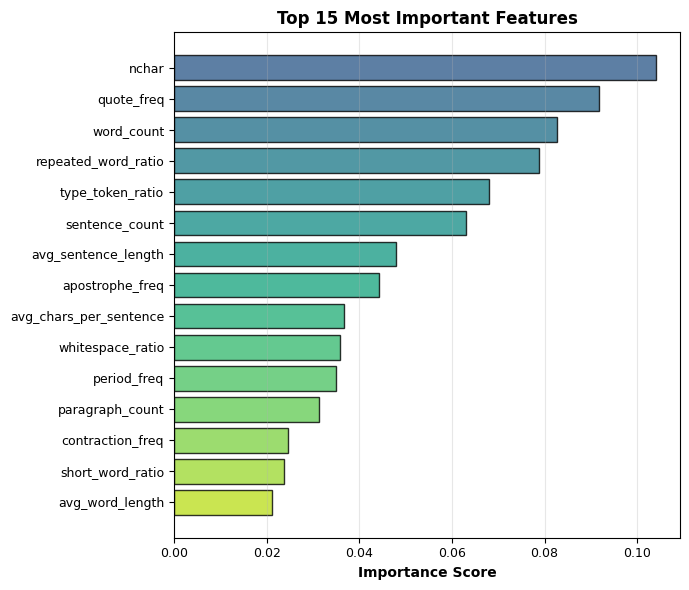

In [ ]:
# Plot a horizontal bar chart of the top 15 most important Random Forest features
fig, ax = plt.subplots(figsize=(7, 6))

# Select top 15 features and assign a color gradient across bars
top_features = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))

ax.barh(
    top_features['Feature'],
    top_features['Importance'],
    color=colors,
    edgecolor='black',
    alpha=0.8
)

ax.set_xlabel('Importance Score', fontsize=10, fontweight='bold')
ax.set_title('Top 15 Most Important Features', fontsize=12, fontweight='bold')

# Invert y-axis so the most important feature appears at the top
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import json
import logging
import os
import random
import sys
from datetime import datetime
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from tqdm import tqdm

In [ ]:
CONFIG = {
    "data_path":       "balanced_sample_70k.parquet",
    "samples":         0,
    "train_ratio":     0.70,
    "val_ratio":       0.15,
    "seed":            42,
    "model_name":      "distilbert-base-uncased",
    "max_length":      256,
    "epochs":          3,
    "batch_size":      128,
    "learning_rate":   5e-5,
    "weight_decay":    0.01,
    "warmup_ratio":    0.1,
    "label_smoothing": 0.05,
    "grad_clip":       1.0,
    "patience":        2,
    "output_dir":      "outputs",
    "save_figure":     True,
    "log_level":       "INFO",
}

AI_KEYWORDS = frozenset([
    "ai", "gpt", "llm", "machine", "generated",
    "synthetic", "claude", "gemini", "chatgpt", "bot",
])

SEP = "=" * 70
print("Config OK")

Config OK


In [ ]:
# Set up output paths, logging, random seeds, and device
out_dir = Path(CONFIG["output_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

log_path  = out_dir / "run.log"
ckpt_path = out_dir / "best_model.pt"
fig_path  = out_dir / "training_curves.png"
hist_path = out_dir / "training_history.json"
cfg_path  = out_dir / "run_config.json"

_lg = logging.getLogger("classifier")
_lg.handlers.clear()
_lg.setLevel(getattr(logging, CONFIG["log_level"]))
_lg.propagate = False
_fmt = logging.Formatter("%(asctime)s  %(levelname)-8s  %(message)s", datefmt="%H:%M:%S")
_sh = logging.StreamHandler(sys.stdout)
_sh.setFormatter(_fmt)
_lg.addHandler(_sh)
_fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
_fh.setFormatter(_fmt)
_lg.addHandler(_fh)
logger = _lg

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
torch.cuda.manual_seed_all(CONFIG["seed"])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(cfg_path, "w", encoding="utf-8") as _f:
    json.dump(dict(list(CONFIG.items()) + [
        ("device", str(device)),
        ("timestamp", datetime.now().isoformat()),
    ]), _f, indent=2)

print(f"Device: {device}")
print(f"Output: {out_dir}")

Device: cuda
Output: outputs


In [ ]:
class TextDataset(Dataset):
    # PyTorch Dataset that tokenizes text samples on-the-fly for transformer input.
    def __init__(self, dataframe, tokenizer, max_length):
        self.texts      = dataframe["text"].tolist()
        self.labels     = dataframe["label"].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [ ]:
# Map labels and apply to the shared train/val/test split (same rows as RF)
_df = pd.read_parquet(CONFIG["data_path"])

label_map = {
    src: (1 if any(k in str(src).lower() for k in AI_KEYWORDS) else 0)
    for src in _df["source"].unique()
}
if len(set(label_map.values())) < 2:
    _srcs = list(_df["source"].unique())
    label_map = {_srcs[0]: 0, _srcs[1]: 1}

# Apply label mapping to the shared splits (same rows as RF -- defined above)
for _split in [train_split, val_split, test_split]:
    _split["label"] = _split["source"].map(label_map).astype(int)

train_df = train_split.dropna(subset=["label", "text"]).reset_index(drop=True)
val_df   = val_split.dropna(subset=["label", "text"]).reset_index(drop=True)
test_df  = test_split.dropna(subset=["label", "text"]).reset_index(drop=True)

mrow("Train", "{:,}  ({:.1f}%)".format(len(train_df), len(train_df) / _n * 100))
mrow("Val",   "{:,}  ({:.1f}%)".format(len(val_df),   len(val_df)   / _n * 100))
mrow("Test",  "{:,}  ({:.1f}%)".format(len(test_df),  len(test_df)  / _n * 100))

  Train............................. 49,000  (70.0%)
  Val............................... 10,500  (15.0%)
  Test.............................. 10,500  (15.0%)


In [ ]:
# Load tokenizer and create DataLoaders for train, validation, and test sets
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

_workers = min(4, os.cpu_count() or 1)
_kw = dict(batch_size=CONFIG["batch_size"], num_workers=_workers, pin_memory=True)

train_loader = DataLoader(
    TextDataset(train_df, tokenizer, CONFIG["max_length"]),
    shuffle=True, **_kw)
val_loader = DataLoader(
    TextDataset(val_df, tokenizer, CONFIG["max_length"]),
    shuffle=False, **_kw)
test_loader = DataLoader(
    TextDataset(test_df, tokenizer, CONFIG["max_length"]),
    shuffle=False, **_kw)

mrow("Batch size",         CONFIG["batch_size"])
mrow("Max token length",   CONFIG["max_length"])
mrow("Train batches",      len(train_loader))
mrow("Val   batches",      len(val_loader))
mrow("Test  batches",      len(test_loader))
mrow("DataLoader workers", _workers)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Batch size........................ 128
  Max token length.................. 256
  Train batches..................... 383
  Val   batches..................... 83
  Test  batches..................... 83
  DataLoader workers................ 2


In [ ]:
# Load pre-trained transformer model for binary sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=2,
).to(device)

_total_p     = sum(p.numel() for p in model.parameters())
_trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
mrow("Total parameters",     "{:,}".format(_total_p))
mrow("Trainable parameters", "{:,}".format(_trainable_p))

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total parameters.................. 66,955,010
  Trainable parameters.............. 66,955,010


In [ ]:
# Configure optimizer, learning rate scheduler, and loss function
_total_steps  = len(train_loader) * CONFIG["epochs"]
_warmup_steps = int(_total_steps * CONFIG["warmup_ratio"])

optimizer = AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    eps=1e-8,
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=_warmup_steps,
    num_training_steps=_total_steps,
)
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])

mrow("Learning rate",       CONFIG["learning_rate"])
mrow("Weight decay",        CONFIG["weight_decay"])
mrow("Label smoothing",     CONFIG["label_smoothing"])
mrow("Grad clip",           CONFIG["grad_clip"] if CONFIG["grad_clip"] > 0.0 else "disabled")
mrow("Warmup steps",        "{:,}".format(_warmup_steps))
mrow("Total steps",         "{:,}".format(_total_steps))
mrow("Early-stop patience", CONFIG["patience"])

  Learning rate..................... 5e-05
  Weight decay...................... 0.01
  Label smoothing................... 0.05
  Grad clip......................... 1.0
  Warmup steps...................... 114
  Total steps....................... 1,149
  Early-stop patience............... 2


In [ ]:
# Input:  model, loader, optimizer, scheduler, criterion, device - training components
#         grad_clip (float), epoch (int), n_epochs (int) - training controls
# Output: tuple of (avg_loss, accuracy, last_lr) for the epoch

def train_one_epoch(model, loader, optimizer, scheduler,
                    criterion, device, grad_clip, epoch, n_epochs):
    # Runs one full training epoch with gradient clipping and live progress display.
    model.train()
    ep_loss    = 0.0
    ep_correct = 0
    ep_total   = 0

    pbar = tqdm(loader,
                desc="  Epoch {:02d}/{:02d}".format(epoch, n_epochs),
                unit="batch", leave=False, ncols=110)

    for step, batch in enumerate(pbar, 1):
        ids    = batch["input_ids"].to(device, non_blocking=True)
        mask   = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(input_ids=ids, attention_mask=mask).logits
        loss   = criterion(logits, labels)
        loss.backward()

        if grad_clip > 0.0:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        scheduler.step()

        ep_loss    += loss.item()
        ep_correct += int((torch.argmax(logits, dim=-1) == labels).sum())
        ep_total   += labels.size(0)

        pbar.set_postfix(
            loss="{:.4f}".format(ep_loss / step),
            acc= "{:.3f}".format(ep_correct / ep_total),
            lr=  "{:.2e}".format(scheduler.get_last_lr()[0]),
        )

    pbar.close()
    return (ep_loss / len(loader),
            ep_correct / ep_total,
            scheduler.get_last_lr()[0])

In [ ]:
# Input:  model, loader, criterion, device - evaluation components
# Output: dict with loss, accuracy, f1, precision, recall, auc, preds, and labels

def evaluate(model, loader, criterion, device):
    # Runs inference over the full loader and returns a complete set of evaluation metrics.
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for batch in loader:
            ids    = batch["input_ids"].to(device, non_blocking=True)
            mask   = batch["attention_mask"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            logits = model(input_ids=ids, attention_mask=mask).logits
            total_loss += criterion(logits, labels).item()
            all_probs.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().tolist())
            all_preds.extend(torch.argmax(logits, dim=-1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    return {
        "loss":      total_loss / len(loader),
        "accuracy":  accuracy_score(all_labels, all_preds),
        "f1":        f1_score(all_labels, all_preds, average="binary", zero_division=0),
        "precision": precision_score(all_labels, all_preds, average="binary", zero_division=0),
        "recall":    recall_score(all_labels, all_preds, average="binary", zero_division=0),
        "auc":       roc_auc_score(all_labels, all_probs),
        "preds":     all_preds,
        "labels":    all_labels,
        "all_probs": all_probs,
    }

In [ ]:
# Train the model with early stopping, saving the best checkpoint by validation F1
history = {k: [] for k in [
    "train_loss", "train_acc", "val_loss",
    "val_acc",    "val_f1",    "val_auc", "lr",
]}
best_val_f1 = 0.0
best_epoch  = 0
no_improve  = 0
run_start   = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    t0 = time.time()

    train_loss, train_acc, cur_lr = train_one_epoch(
        model, train_loader, optimizer, scheduler,
        criterion, device, CONFIG["grad_clip"],
        epoch, CONFIG["epochs"],
    )
    vm      = evaluate(model, val_loader, criterion, device)
    elapsed = time.time() - t0

    if vm["f1"] > best_val_f1:
        best_val_f1 = vm["f1"]
        best_epoch  = epoch
        no_improve  = 0
        torch.save({"epoch":       epoch,
                    "model_state": model.state_dict(),
                    "val_f1":      best_val_f1,
                    "config":      CONFIG},
                   ckpt_path)
        flag = "  BEST"
    else:
        no_improve += 1
        flag = "  (no improve {}/{})".format(no_improve, CONFIG["patience"])

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(vm["loss"])
    history["val_acc"].append(vm["accuracy"])
    history["val_f1"].append(vm["f1"])
    history["val_auc"].append(vm["auc"])
    history["lr"].append(cur_lr)

    logger.info("Ep %02d  train_loss=%.4f  val_loss=%.4f  val_f1=%.4f  val_auc=%.4f",
                epoch, train_loss, vm["loss"], vm["f1"], vm["auc"])
    print("  {:<3}  {:>10.4f}  {:>9.4f}  {:>9.4f}  {:>8.4f}  {:>7.4f}  {:>8.4f}  {:>9.2e}  {:>4.1f}s{}".format(
        epoch, train_loss, train_acc, vm["loss"], vm["accuracy"],
        vm["f1"], vm["auc"], cur_lr, elapsed, flag))

    if no_improve >= CONFIG["patience"]:
        logger.info("Early stopping at epoch %d.", epoch)
        break

total_time = time.time() - run_start
mrow("Runtime",    "{:.1f} min".format(total_time / 60))
mrow("Best epoch", "{}  (Val F1 = {:.4f})".format(best_epoch, best_val_f1))

08:44:09  INFO      Ep 01  train_loss=0.2793  val_loss=0.2020  val_f1=0.9576  val_auc=0.9944
  1        0.2793     0.9114     0.2020    0.9562   0.9576    0.9944   3.70e-05  1196.5s  BEST


09:04:12  INFO      Ep 02  train_loss=0.1620  val_loss=0.2275  val_f1=0.9532  val_auc=0.9943
  2        0.1620     0.9791     0.2275    0.9513   0.9532    0.9943   1.85e-05  1203.3s  (no improve 1/2)


09:24:20  INFO      Ep 03  train_loss=0.1318  val_loss=0.2158  val_f1=0.9605  val_auc=0.9900
  3        0.1318     0.9939     0.2158    0.9592   0.9605    0.9900   0.00e+00  1202.5s  BEST
  Runtime........................... 60.5 min
  Best epoch........................ 3  (Val F1 = 0.9605)


In [ ]:
tokenizer.save_pretrained('outputs/tokenizer')
print("Saved: tokenizer")

Saved: tokenizer


In [ ]:
# Load best checkpoint and evaluate on the test set
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])

tm = evaluate(model, test_loader, criterion, device)
history["test_loss"] = tm["loss"]

mrow("Loss",      "{:.4f}".format(tm["loss"]))
mrow("Accuracy",  "{:.2f}%".format(tm["accuracy"] * 100))
mrow("F1 Score",  "{:.4f}".format(tm["f1"]))
mrow("Precision", "{:.4f}".format(tm["precision"]))
mrow("Recall",    "{:.4f}".format(tm["recall"]))
mrow("ROC-AUC",   "{:.4f}".format(tm["auc"]))
print()
print(classification_report(tm["labels"], tm["preds"], target_names=["Human", "AI"], digits=4))

  Loss.............................. 0.2246
  Accuracy.......................... 95.77%
  F1 Score.......................... 0.9591
  Precision......................... 0.9294
  Recall............................ 0.9907
  ROC-AUC........................... 0.9859

              precision    recall  f1-score   support

       Human     0.9900    0.9248    0.9563      5250
          AI     0.9294    0.9907    0.9591      5250

    accuracy                         0.9577     10500
   macro avg     0.9597    0.9577    0.9577     10500
weighted avg     0.9597    0.9577    0.9577     10500



In [ ]:
# Input:  ax (Axes), title (str), ylabel (str), xs (list) - axis and label config
# Output: styled matplotlib axis in-place
def _style_axis(ax, title, ylabel, xs):
    # Applies consistent visual styling to a subplot axis.
    ax.set_title(title,    fontsize=12, fontweight="bold", color="#1e293b", pad=9)
    ax.set_xlabel("Epoch", fontsize=9,  color="#475569")
    ax.set_ylabel(ylabel,  fontsize=9,  color="#475569")
    ax.tick_params(labelsize=8, labelcolor="#475569")
    ax.grid(True, color="#e2e8f0", linewidth=0.7, linestyle="--")
    ax.set_facecolor("#ffffff")
    for spine in ax.spines.values():
        spine.set_edgecolor("#cbd5e1")
    ax.set_xticks(xs)

    # Input:  history (dict), tm (dict), best_epoch (int), cfg (dict), out_path (Path)
# Output: saves and displays the full training dashboard figure
def save_figure(history, tm, best_epoch, cfg, out_path):
    # Renders a 6-panel training dashboard including loss, accuracy, F1/AUC, LR, confusion matrix, and summary table.
    xs   = list(range(1, len(history["train_loss"]) + 1))
    slbl = str(cfg["samples"]) if cfg["samples"] > 0 else "all"

    C_TR = "#2563EB"; C_VA = "#16A34A"; C_TE = "#DC2626"
    C_AU = "#7C3AED"; C_F1 = "#D97706"; C_LR = "#64748B"
    C_GP = "#F59E0B"; C_BT = "#94A3B8"

    fig = plt.figure(figsize=(18, 13), facecolor="#f8fafc")
    fig.suptitle("AI vs Human Classifier -- Training Dashboard",
                 fontsize=15, fontweight="bold", color="#0f172a", y=0.998)
    fig.text(0.5, 0.980,
             "model={}  |  samples={}  |  epochs={}  |  lr={}  |  "
             "batch={}  |  max_len={}  |  seed={}".format(
                 cfg["model_name"], slbl, cfg["epochs"],
                 cfg["learning_rate"], cfg["batch_size"],
                 cfg["max_length"], cfg["seed"]),
             ha="center", fontsize=8, color="#64748b", style="italic")
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.44, wspace=0.35,
                           left=0.07, right=0.97, top=0.945, bottom=0.07)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(xs, history["train_loss"], color=C_TR, lw=2.2, marker="o", ms=5, label="Train")
    ax1.plot(xs, history["val_loss"],   color=C_VA, lw=2.2, marker="s", ms=5, label="Validation")
    ax1.axhline(history["test_loss"], color=C_TE, lw=1.6, linestyle=":", alpha=0.85,
                label="Test  {:.4f}".format(history["test_loss"]))
    ax1.fill_between(xs, history["train_loss"], history["val_loss"],
                     alpha=0.07, color=C_GP, label="Train/Val gap")
    ax1.axvline(best_epoch, color=C_BT, lw=1.2, linestyle="--", alpha=0.65)
    mvl = min(history["val_loss"])
    ax1.annotate("Best\nEp {}".format(best_epoch),
                 xy=(best_epoch, mvl),
                 xytext=(best_epoch + 0.25, mvl + 0.025),
                 fontsize=7.5, color="#475569",
                 arrowprops=dict(arrowstyle="->", color=C_BT, lw=0.9))
    _style_axis(ax1, "1  Cross-Entropy Loss", "Loss", xs)
    ax1.legend(fontsize=7.5, framealpha=0.9, loc="upper right")

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(xs, history["train_acc"], color=C_TR, lw=2.2, marker="o", ms=5, label="Train")
    ax2.plot(xs, history["val_acc"],   color=C_VA, lw=2.2, marker="s", ms=5, label="Validation")
    ax2.axhline(tm["accuracy"], color=C_TE, lw=1.6, linestyle=":", alpha=0.85,
                label="Test  {:.1f}%".format(tm["accuracy"] * 100))
    ax2.axvline(best_epoch, color=C_BT, lw=1.2, linestyle="--", alpha=0.65)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: "{:.0f}%".format(y * 100)))
    _style_axis(ax2, "2  Accuracy", "Accuracy", xs)
    ax2.legend(fontsize=7.5, framealpha=0.9)

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(xs, history["val_f1"],  color=C_F1, lw=2.2, marker="D", ms=5, label="Val F1")
    ax3.plot(xs, history["val_auc"], color=C_AU, lw=2.2, marker="^", ms=5, label="Val AUC")
    ax3.axhline(tm["f1"],  color=C_F1, lw=1.5, linestyle=":", alpha=0.85,
                label="Test F1   {:.4f}".format(tm["f1"]))
    ax3.axhline(tm["auc"], color=C_AU, lw=1.5, linestyle=":", alpha=0.85,
                label="Test AUC  {:.4f}".format(tm["auc"]))
    ax3.axvline(best_epoch, color=C_BT, lw=1.2, linestyle="--", alpha=0.65)
    ax3.set_ylim(0, 1.05)
    _style_axis(ax3, "3  F1 and ROC-AUC", "Score", xs)
    ax3.legend(fontsize=7.5, framealpha=0.9)

    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(xs, history["lr"], color=C_LR, lw=2.2, marker="o", ms=5, label="LR")
    ax4.fill_between(xs, history["lr"], alpha=0.12, color=C_LR)
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: "{:.1e}".format(y)))
    _style_axis(ax4, "4  Learning-Rate Schedule", "LR", xs)
    ax4.legend(fontsize=7.5, framealpha=0.9)

    ax5 = fig.add_subplot(gs[1, 1])
    cm_raw  = confusion_matrix(tm["labels"], tm["preds"])
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)
    im = ax5.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)
    ax5.set_xticks([0, 1]); ax5.set_yticks([0, 1])
    ax5.set_xticklabels(["Human", "AI"], fontsize=9, color="#475569")
    ax5.set_yticklabels(["Human", "AI"], fontsize=9, color="#475569")
    ax5.set_xlabel("Predicted", fontsize=9, color="#475569")
    ax5.set_ylabel("Actual",    fontsize=9, color="#475569")
    ax5.set_title("5  Confusion Matrix (normalised)", fontsize=12, fontweight="bold", color="#1e293b", pad=9)
    for i in range(2):
        for j in range(2):
            ax5.text(j, i,
                     "{}\n({:.1f}%)".format(cm_raw[i, j], cm_norm[i, j] * 100),
                     ha="center", va="center", fontsize=10, fontweight="bold",
                     color="white" if cm_norm[i, j] > 0.55 else "#1e293b")

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis("off")
    rows = [
        ["Metric",    "Train",   "Validation", "Test"],
        ["Loss",
         "{:.4f}".format(history["train_loss"][-1]),
         "{:.4f}".format(history["val_loss"][-1]),
         "{:.4f}".format(tm["loss"])],
        ["Accuracy",
         "{:.1f}%".format(history["train_acc"][-1] * 100),
         "{:.1f}%".format(history["val_acc"][-1]   * 100),
         "{:.1f}%".format(tm["accuracy"]           * 100)],
        ["F1", "-", "{:.4f}".format(history["val_f1"][-1]),  "{:.4f}".format(tm["f1"])],
        ["AUC", "-", "{:.4f}".format(history["val_auc"][-1]), "{:.4f}".format(tm["auc"])],
        ["Precision", "-", "-", "{:.4f}".format(tm["precision"])],
        ["Recall",    "-", "-", "{:.4f}".format(tm["recall"])],
    ]
    cx = [0.03, 0.25, 0.50, 0.76]
    cw = [0.22, 0.25, 0.26, 0.24]
    rh = 0.105
    y0 = 0.935
    for r, row in enumerate(rows):
        y = y0 - r * rh
        for c, cell in enumerate(row):
            ih = (r == 0)
            bg = ("#1e3a5f" if ih else "#dbeafe" if r % 2 == 0 else "#ffffff")
            fc = "white" if ih else "#1e293b"
            fw = "bold"  if (ih or c == 0) else "normal"
            fs = 8.5     if ih else 8.0
            ax6.add_patch(plt.Rectangle(
                (cx[c], y - rh * 0.82), cw[c], rh * 0.88,
                transform=ax6.transAxes,
                facecolor=bg, edgecolor="#cbd5e1", lw=0.5))
            ax6.text(cx[c] + cw[c] / 2.0, y - rh * 0.30, cell,
                     transform=ax6.transAxes,
                     ha="center", va="center",
                     fontsize=fs, fontweight=fw, color=fc)
    ax6.set_title("6  Summary Metrics", fontsize=12, fontweight="bold", color="#1e293b", pad=9)
    ax6.text(0.5, 0.005,
             "Best epoch: {}  |  patience: {}  |  samples: {}  |  smoothing: {}".format(
                 best_epoch, cfg["patience"], slbl, cfg["label_smoothing"]),
             transform=ax6.transAxes, ha="center", va="bottom",
             fontsize=7, color="#64748b", style="italic")

    fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    plt.close(fig)

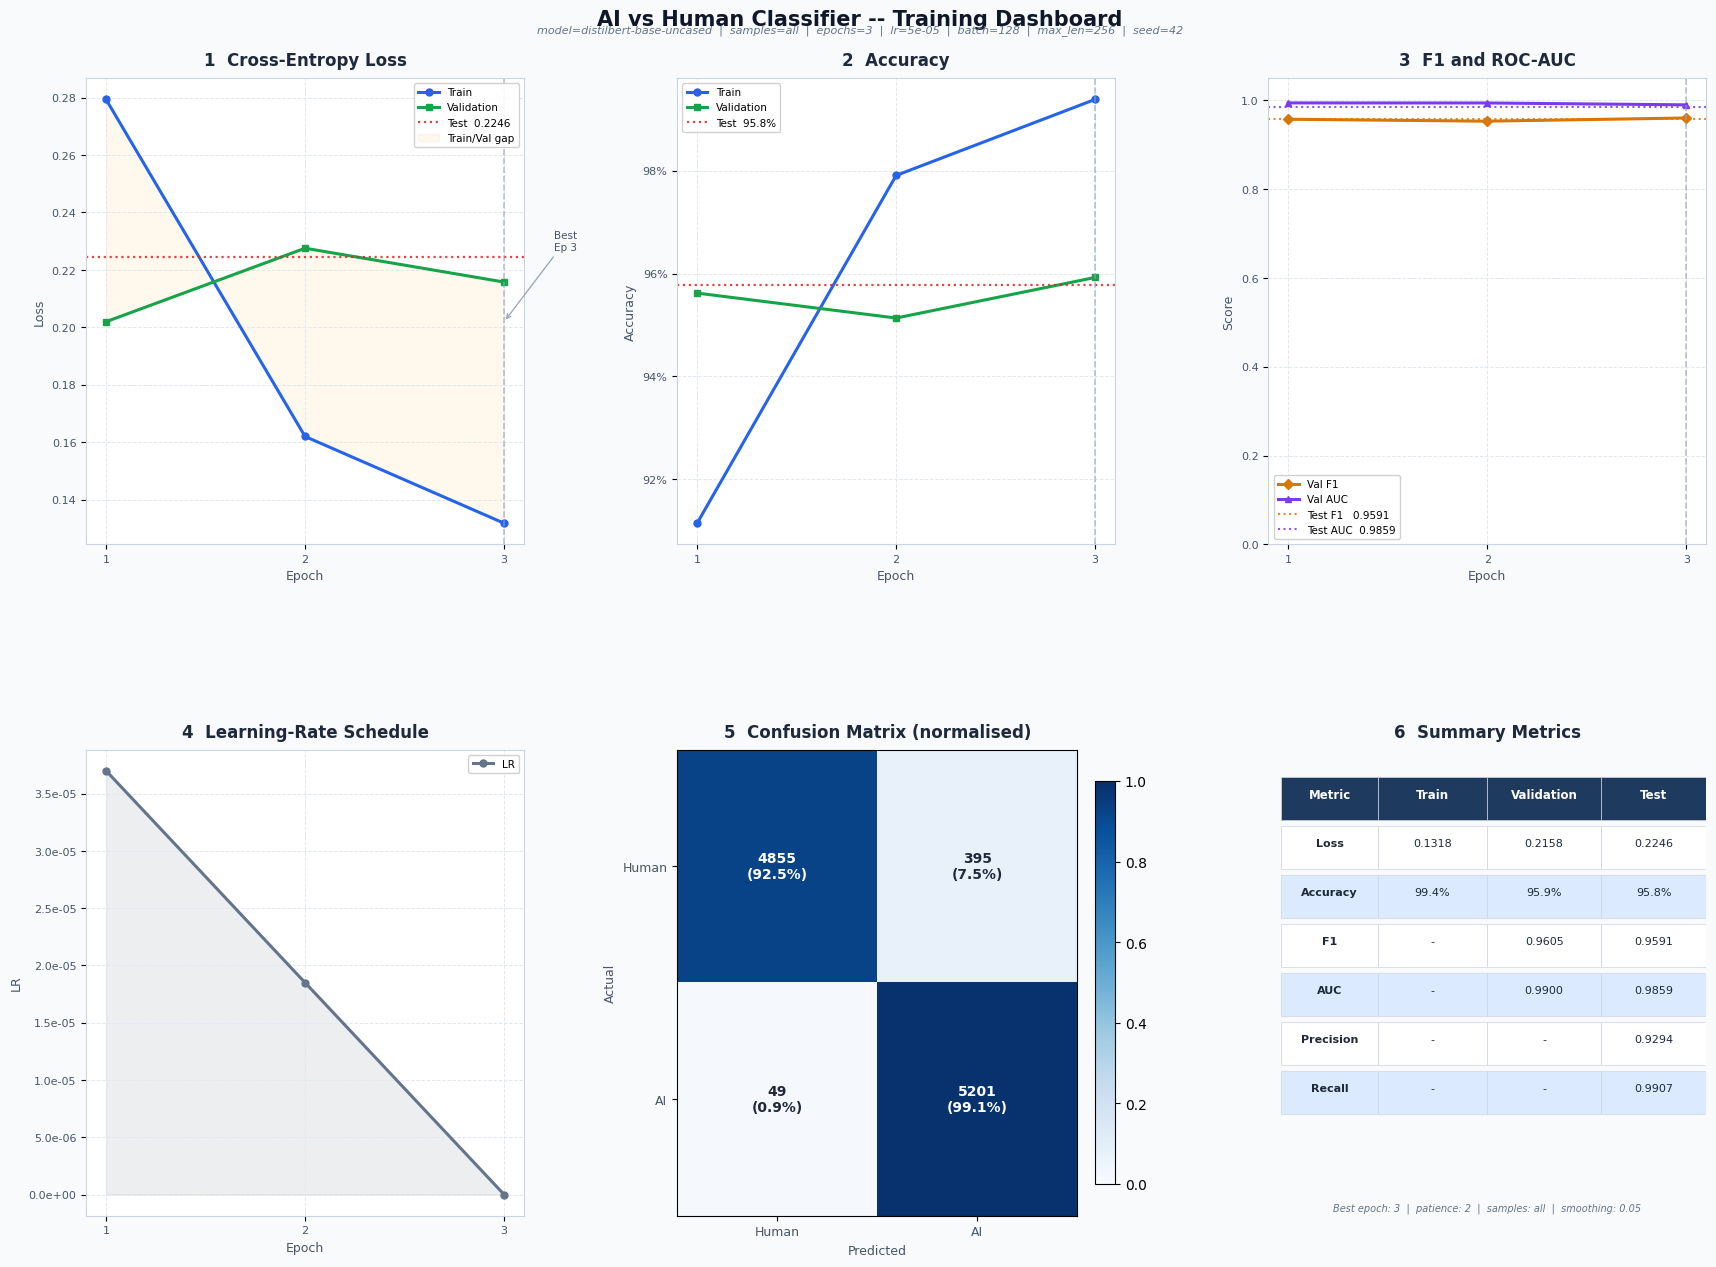

In [ ]:
# Save training history, config, and figure
with open(hist_path, "w", encoding="utf-8") as _f:
    json.dump(history, _f, indent=2)

if CONFIG["save_figure"]:
    save_figure(history, tm, best_epoch, CONFIG, fig_path)

In [ ]:
# Input:  texts (str or list of str) - text(s) to classify
#         model, tokenizer, device - inference components
#         max_length (int) - maximum token sequence length (default: 256)
# Output: list of dicts with 'label', 'confidence', 'p_human', 'p_ai' per sample

def predict(texts, model, tokenizer, device, max_length=256):
    # Runs inference on one or more texts and returns class probabilities and predicted label.
    model.eval()
    tlist = [texts] if isinstance(texts, str) else list(texts)
    enc = tokenizer(tlist, padding="max_length", truncation=True,
                    max_length=max_length, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=1)
    return [
        {"label":      "AI" if p == 1 else "Human",
         "confidence": float(prob[p]),
         "p_human":    float(prob[0]),
         "p_ai":       float(prob[1])}
        for p, prob in zip(preds, probs)
    ]


# Run inference on 4 test samples to verify predictions
for _i in range(min(4, len(test_df))):
    _row    = test_df.iloc[_i]
    _result = predict(_row["text"], model, tokenizer, device, CONFIG["max_length"])[0]
    _actual = "AI" if _row["label"] == 1 else "Human"
    _ok     = "OK" if _actual == _result["label"] else "WRONG"
    _snip   = str(_row["text"])[:78].replace("\n", " ")
    print("  [{}] Actual: {:<7}  Pred: {:<7}  Conf: {:.3f}  \"{}...\"".format(
        _ok, _actual, _result["label"], _result["confidence"], _snip))

  [OK] Actual: AI       Pred: AI       Conf: 0.976  "In this Wednesday, Jan. 11, 2015 photo, a water fountain is seen on a downtown..."
  [OK] Actual: AI       Pred: AI       Conf: 0.975  "A little more than three months ago, after a month of investigation, the U.S. ..."
  [OK] Actual: AI       Pred: AI       Conf: 0.977  "The first year with C# and D.NET was quite a rocky one. We were so over the mo..."
  [OK] Actual: Human    Pred: Human    Conf: 0.978  " almost two am? Even little ones were out and about unsupervised no one with a..."


In [ ]:
# Input:  test_df (DataFrame) - original test set with 'text' and 'label' columns
#         tm (dict) - evaluation results containing 'preds' and 'labels'
# Output: DataFrame of misclassified samples with text, true and predicted labels

def get_transformer_misclassified(test_df, tm):
    # Extracts all misclassified Transformer samples for error analysis and cross-model comparison.
    preds  = np.array(tm["preds"])
    labels = np.array(tm["labels"])
    mask   = preds != labels

    misclassified_df = test_df[mask].copy().reset_index(drop=True)
    misclassified_df['true_label']      = np.where(labels[mask] == 1, 'ai', 'human')
    misclassified_df['predicted_label'] = np.where(preds[mask]  == 1, 'ai', 'human')

    mrow("Misclassified samples", len(misclassified_df))
    misclassified_df.to_csv('transformer_misclassified.csv', index=False)
    return misclassified_df

transformer_misclassified = get_transformer_misclassified(test_df, tm)

mrow("Runtime",    "{:.1f} min".format(total_time / 60))
mrow("Device",     str(device))
mrow("Best epoch", "{}  (Val F1 = {:.4f})".format(best_epoch, best_val_f1))
mrow("Output dir", str(out_dir))

  Misclassified samples............. 444
  Runtime........................... 60.5 min
  Device............................ cuda
  Best epoch........................ 3  (Val F1 = 0.9605)
  Output dir........................ outputs


In [ ]:
# Input:  rf_metrics (dict) - RF evaluation metrics
#         tm (dict)         - Transformer evaluation dict
# Output: unified comparison DataFrame with per-metric winner annotation
def build_comparison_df(rf_metrics, tm):
    metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    rf_vals = [rf_metrics["test_acc"], rf_metrics["test_precision"],
               rf_metrics["test_recall"], rf_metrics["test_f1"], rf_metrics["test_auc"]]
    tr_vals = [tm["accuracy"], tm["precision"], tm["recall"], tm["f1"], tm["auc"]]

    return pd.DataFrame({
        "Metric":        metrics,
        "Random Forest": rf_vals,
        "Transformer":   tr_vals,
        # Automatically determine the better model per metric
        "Winner":        ["Transformer" if t > r else ("RF" if r > t else "Tie")
                          for r, t in zip(rf_vals, tr_vals)]
    })

comparison_df = build_comparison_df(rf_metrics, tm)
comparison_df.to_csv("model_comparison.csv", index=False)

In [ ]:
# Input:  comparison_df (DataFrame) - unified metrics table
#         rf_metrics (dict), tm (dict) - for train time row
# Output: prints and saves the formatted summary table
def print_summary_table(comparison_df, rf_metrics, tm):

    # Append train time row separately (mixed types: numeric vs string)
    tr_time  = "{:.1f} sec".format(tm["train_time"]) if "train_time" in tm else "~20 min (GPU)"
    time_row = pd.DataFrame([{
        "Metric":        "Train Time",
        "Random Forest": "{:.1f} sec".format(rf_metrics["train_time"]),
        "Transformer":   tr_time,
        "Winner":        "RF"  # RF always wins on speed
    }])

    # Format numeric columns as percentages or 4 decimal places for display
    display_df = pd.concat([comparison_df, time_row], ignore_index=True)
    display_df["Random Forest"] = display_df.apply(
        lambda row: "{:.2f}%".format(row["Random Forest"] * 100)
        if row["Metric"] == "Accuracy" and isinstance(row["Random Forest"], float)
        else ("{:.4f}".format(row["Random Forest"])
              if isinstance(row["Random Forest"], float) else row["Random Forest"]),
        axis=1
    )
    display_df["Transformer"] = display_df.apply(
        lambda row: "{:.2f}%".format(row["Transformer"] * 100)
        if row["Metric"] == "Accuracy" and isinstance(row["Transformer"], float)
        else ("{:.4f}".format(row["Transformer"])
              if isinstance(row["Transformer"], float) else row["Transformer"]),
        axis=1
    )

    print("\n" + "=" * 65)
    print("  MODEL COMPARISON SUMMARY")
    print("=" * 65)
    print(display_df.to_string(index=False))
    print("=" * 65)

    display_df.to_csv("model_comparison_summary.csv", index=False)
    print("Saved: model_comparison_summary.csv")
    return display_df

# Print and save the final side-by-side model comparison summary
print_summary_table(comparison_df, rf_metrics, tm)


  MODEL COMPARISON SUMMARY
    Metric Random Forest   Transformer      Winner
  Accuracy        89.24%        95.77% Transformer
 Precision        0.8507        0.9294 Transformer
    Recall        0.9518        0.9907 Transformer
  F1 Score        0.8984        0.9591 Transformer
   ROC-AUC        0.9580        0.9859 Transformer
Train Time      21.5 sec ~20 min (GPU)          RF
Saved: model_comparison_summary.csv


,Metric,Random Forest,Transformer,Winner
0,Accuracy,89.24%,95.77%,Transformer
1,Precision,0.8507,0.9294,Transformer
2,Recall,0.9518,0.9907,Transformer
3,F1 Score,0.8984,0.9591,Transformer
4,ROC-AUC,0.9580,0.9859,Transformer
5,Train Time,21.5 sec,~20 min (GPU),RF


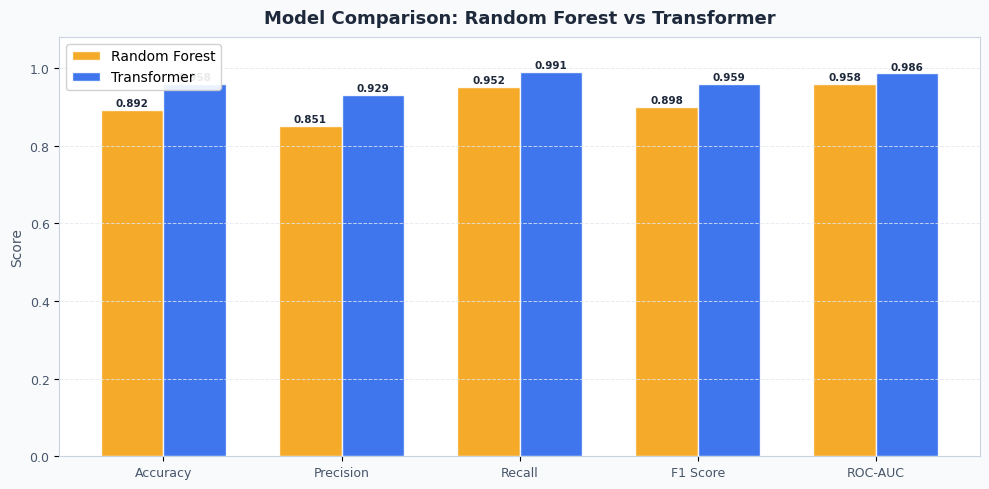

Saved: bar_comparison.png


In [ ]:
# Plot a grouped bar chart comparing all metrics between both models
x     = np.arange(len(comparison_df))
width = 0.35

C_RF = "#F59E0B"
C_TR = "#2563EB"

fig, ax = plt.subplots(figsize=(10, 5), facecolor="#f8fafc")

bars_rf = ax.bar(x - width/2, comparison_df["Random Forest"], width,
                 label="Random Forest", color=C_RF, alpha=0.88, edgecolor="white")
bars_tr = ax.bar(x + width/2, comparison_df["Transformer"],   width,
                 label="Transformer",   color=C_TR, alpha=0.88, edgecolor="white")

# Annotate each bar with its numeric value
for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            "{:.3f}".format(bar.get_height()), ha="center", va="bottom",
            fontsize=7.5, color="#1e293b", fontweight="bold")
for bar in bars_tr:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            "{:.3f}".format(bar.get_height()), ha="center", va="bottom",
            fontsize=7.5, color="#1e293b", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Metric"], fontsize=10, color="#475569")
ax.set_ylabel("Score", fontsize=10, color="#475569")
ax.set_ylim(0, 1.08)
ax.set_title("Model Comparison: Random Forest vs Transformer",
             fontsize=13, fontweight="bold", color="#1e293b", pad=10)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis="y", color="#e2e8f0", linewidth=0.7, linestyle="--", alpha=0.8)
ax.set_facecolor("#ffffff")
for sp in ax.spines.values():
    sp.set_edgecolor("#cbd5e1")
ax.tick_params(labelsize=9, labelcolor="#475569")

plt.tight_layout()
plt.savefig("bar_comparison.png", dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)
print("Saved: bar_comparison.png")

In [ ]:
# Find texts that both models misclassified
rf_texts = set(rf_misclassified['text'].values)
transformer_texts = set(transformer_misclassified['text'].values)

common_texts = rf_texts & transformer_texts

common_errors = transformer_misclassified[transformer_misclassified['text'].isin(common_texts)][['text', 'true_label', 'predicted_label']].reset_index(drop=True)

print(f"Texts misclassified by both models: {len(common_errors)}")
print(f"RF only errors: {len(rf_texts - transformer_texts)}")
print(f"Transformer only errors: {len(transformer_texts - rf_texts)}")

common_errors.to_csv('common_misclassified.csv', index=False)
print("Saved: common_misclassified.csv")

Texts misclassified by both models: 49
RF only errors: 1081
Transformer only errors: 395
Saved: common_misclassified.csv


In [ ]:
import os
import shutil
import torch
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running in Google Colab. Ensure paths exist manually.")

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths configuration
BASE_MODEL_NAME = "distilbert-base-uncased"
PROVIDED_MODEL_PATH = "/content/drive/MyDrive/project_AIDetext/best_model (5).pt"
PROVIDED_TOKENIZER_PATH = "/content/drive/MyDrive/project_AIDetext/tokenizer (1).json"
PROVIDED_CONFIG_PATH = "/content/drive/MyDrive/project_AIDetext/tokenizer_config (1).json"
TOKENIZER_DIR = "/content/local_tokenizer_setup"

# Prepare tokenizer directory
os.makedirs(TOKENIZER_DIR, exist_ok=True)
for src, dst in [(PROVIDED_CONFIG_PATH, "tokenizer_config.json"),
                 (PROVIDED_TOKENIZER_PATH, "tokenizer.json")]:
    if os.path.exists(src):
        shutil.copy(src, os.path.join(TOKENIZER_DIR, dst))
    else:
        print(f"Warning: Missing file at {src}")

# Load tokenizer
try:
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)
except Exception as e:
    print(f"Local tokenizer load failed ({e}). Falling back to base model.")
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

# Load model
model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL_NAME, num_labels=2)
if os.path.exists(PROVIDED_MODEL_PATH):
    checkpoint = torch.load(PROVIDED_MODEL_PATH, map_location=device)
    state_dict = checkpoint['model_state'] if 'model_state' in checkpoint else checkpoint
    model.load_state_dict(state_dict, strict=False)
    print("Custom weights loaded successfully.")
else:
    print(f"Error: Checkpoint not found at {PROVIDED_MODEL_PATH}")

model.to(device)
model.eval()
print("Model ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Custom weights loaded successfully.
Model ready!


In [ ]:
def classify_text(text):
    if not text.strip():
        return {"Please enter a valid text to analyze.": 1.0}

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=256
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).squeeze().tolist()

    if not isinstance(probs, list) or len(probs) < 2:
        return {"Classification failed. Please try again.": 1.0}

    return {
        "Human (Written by Human)": float(probs[0]),
        "AI (Generated by AI)": float(probs[1])
    }

In [ ]:
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🤖 AIDetext — Text Origin Classifier")
    gr.Markdown("A Deep Learning system (DistilBERT) that classifies whether a text was written by a human or generated by AI.")
    gr.Markdown("⚠️ **Note:** This model works on **English text only** and analyzes up to **256 tokens**.")

    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(
                label="Input Text for Analysis",
                placeholder="Paste the English text you want to check here...",
                lines=8
            )
            with gr.Row():
                submit_btn = gr.Button("Analyze Text Origin ✨", variant="primary")
                clear_btn = gr.ClearButton(input_text, value="Clear 🗑️")

        with gr.Column():
            output_label = gr.Label(
                label="Classification Results & Confidence",
                num_top_classes=2
            )

    submit_btn.click(fn=classify_text, inputs=input_text, outputs=output_label)

demo.launch(share=True)

/tmp/ipykernel_3888/725401107.py:1: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://83a0a612c7d1327d63.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
